In [86]:
from pathlib import Path
import pandas as pd

# 查找当前项目目录中的所有xlsx文件
xlsx_files = list(Path.cwd().rglob("*.xlsx"))

if not xlsx_files:
    raise FileNotFoundError("当前项目中未找到任何xlsx文件。")

# 如果有多个xlsx文件，可以选择第一个，或者根据需求做进一步选择
excel_path = xlsx_files[0]

print(f"已找到文件: {excel_path.resolve()}")
df = pd.read_excel(excel_path)
display(df.shape)
df.head()


已找到文件: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\336170440_30000_坐标数据.xlsx


(133, 3)

,答卷序号,点选坐标,提交时间
0,1,364-192→300-226→338-192→322-496→308-148,2025-10-30 10:59:52
1,2,365-210→317-230→159-266→397-220→452-276,2025-10-30 11:01:51
2,3,258-458→357-223→591-661→320-217→506-432,2025-10-30 11:03:48
3,4,342-172→166-260→278-434→415-455→425-588→324-44...,2025-10-30 11:04:59
4,5,321-131→200-175→111-262→361-169→472-407→326-46...,2025-10-30 11:08:38


c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

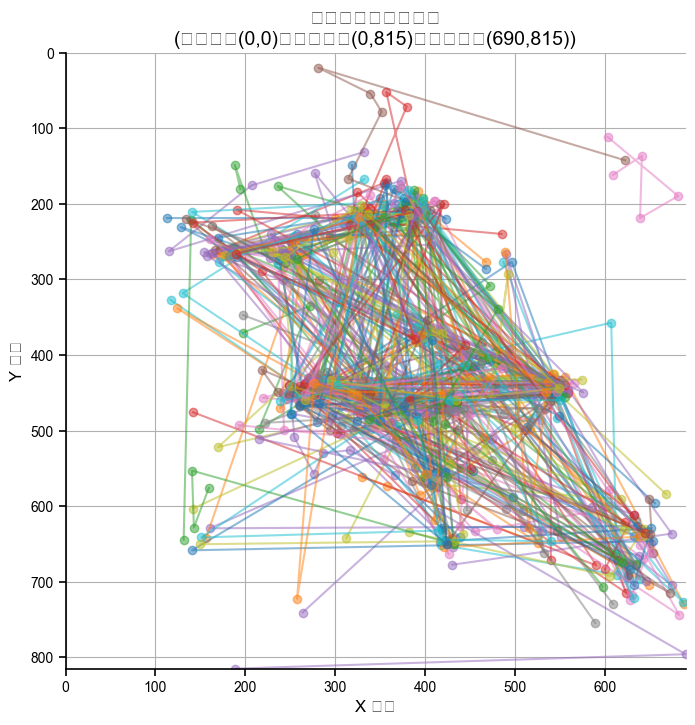

In [87]:
import matplotlib.pyplot as plt

# 假设"点选坐标"这一列存在，并且用→分隔每一对
def parse_coords(coord_str):
    points = coord_str.split('→')
    point_list = []
    for pt in points:
        try:
            x_str, y_str = pt.split('-')
            point_list.append((int(x_str), int(y_str)))
        except Exception as e:
            pass
    return point_list

# 新建一列，将字符串转为点对列表
df['点对'] = df['点选坐标'].apply(parse_coords)

# 计算原始坐标范围（用于缩放到目标坐标系）
raw_max_x, raw_max_y = 0, 0
for points in df['点对']:
    for x, y in points:
        if x > raw_max_x:
            raw_max_x = x
        if y > raw_max_y:
            raw_max_y = y

# 目标坐标系：左上(0,0)、左下(0,815)、右上(690,815)
target_width, target_height = 690, 815
x_scale = (target_width / raw_max_x) if raw_max_x else 1
y_scale = (target_height / raw_max_y) if raw_max_y else 1

# 可视化所有点对（左上角为(0,0) 的坐标系）
plt.figure(figsize=(8, 8))
for points in df['点对']:
    xs = [x * x_scale for x, _ in points]
    ys = [y * y_scale for _, y in points]
    plt.plot(xs, ys, marker='o', alpha=0.5)

plt.title('所有答卷的点选轨迹\n(左上角为(0,0)，左下角为(0,815)，右上角为(690,815))')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.xlim(0, target_width)
plt.ylim(target_height, 0)  # 使y轴向下增大
plt.grid(True)
plt.show()





c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

点坐标: (376.55, -192.71)
点坐标: (310.34, -226.83)
点坐标: (349.66, -192.71)
点坐标: (333.10, -497.83)
点坐标: (318.62, -148.55)
点坐标: (377.59, -210.78)
点坐标: (327.93, -230.85)
点坐标: (164.48, -266.98)
点坐标: (410.69, -220.81)
点坐标: (467.59, -277.02)
点坐标: (266.90, -459.69)
点坐标: (369.31, -223.82)
点坐标: (611.38, -663.44)
点坐标: (331.03, -217.80)
点坐标: (523.45, -433.60)
点坐标: (353.79, -172.64)
点坐标: (171.72, -260.96)
点坐标: (287.59, -435.60)
点坐标: (429.31, -456.68)
点坐标: (439.66, -590.17)
点坐标: (335.17, -450.66)
点坐标: (388.97, -370.36)
点坐标: (538.97, -439.62)
点坐标: (293.79, -243.90)
点坐标: (332.07, -131.48)
点坐标: (206.90, -175.65)
点坐标: (114.83, -262.97)
点坐标: (373.45, -169.62)
点坐标: (488.28, -408.50)
点坐标: (337.24, -464.71)
点坐标: (474.83, -510.88)
点坐标: (263.79, -740.73)
点坐标: (400.34, -569.09)
点坐标: (242.07, -449.66)
点坐标: (293.79, -499.84)
点坐标: (398.28, -212.78)
点坐标: (537.93, -433.60)
点坐标: (347.59, -228.84)
点坐标: (242.07, -285.05)
点坐标: (558.62, -448.65)
点坐标: (284.48, -452.67)
点坐标: (180.00, -261.96)
点坐标: (411.72, -211.78)
点坐标: (428.2

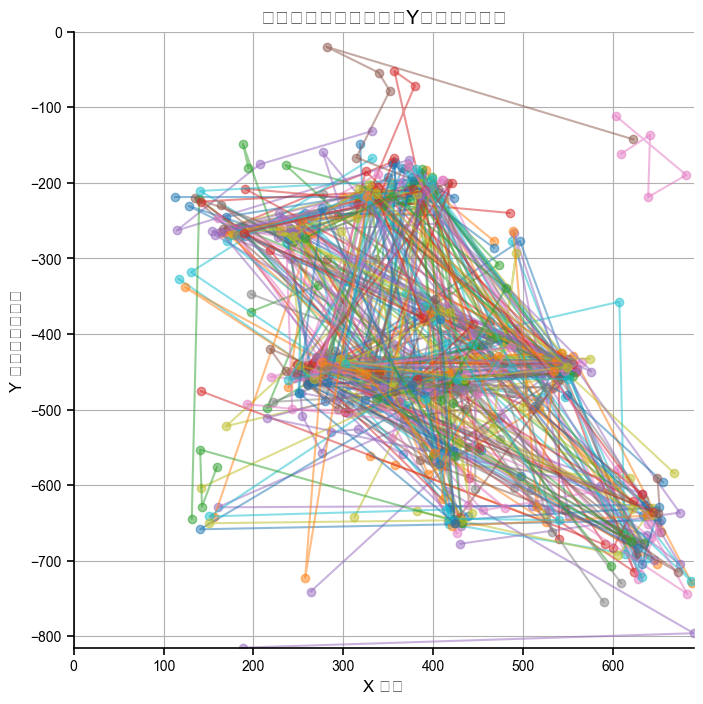

In [88]:
# 可视化所有点对的纵坐标乘以-1后的轨迹，同时输出所有坐标点
plt.figure(figsize=(8, 8))
for points in df['点对']:
    xs = [x * x_scale for x, _ in points]
    ys = [-(y * y_scale) for _, y in points]
    plt.plot(xs, ys, marker='o', alpha=0.5)
    for x_draw, y_draw in zip(xs, ys):
        print(f"点坐标: ({x_draw:.2f}, {y_draw:.2f})")
plt.title('所有答卷的点选轨迹（Y坐标反转后）')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标（已反转）')
plt.xlim(0, target_width)
plt.ylim(-target_height, 0)
plt.grid(True)
plt.show()

,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,-192.709360
1,1,310.344828,-226.834975
2,1,349.655172,-192.709360
3,1,333.103448,-497.832512
4,1,318.620690,-148.546798
...,...,...,...
741,133,424.137931,-562.068966
742,133,257.586207,-273.004926
743,133,353.793103,-216.798030
744,133,481.034483,-339.248768


c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

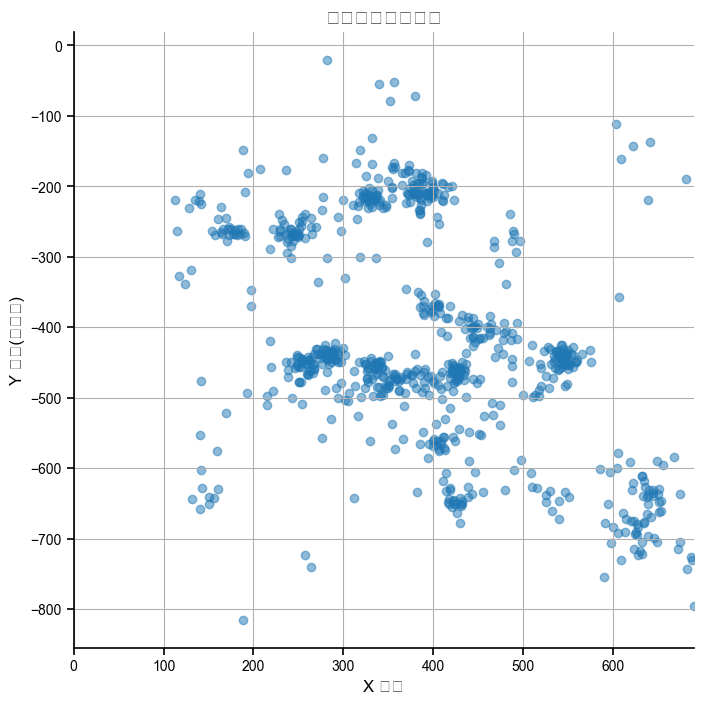

In [89]:

# 输出所有点的坐标组成的DataFrame
all_points = []
for idx, points in enumerate(df['点对']):
    for x, y in points:
        # 这里使用缩放后的坐标，更直观
        scaled_x = x * x_scale
        scaled_y = -(y * y_scale)
        all_points.append({
            '答卷序号': df.iloc[idx]['答卷序号'] if '答卷序号' in df.columns else idx + 1,
            'X坐标': scaled_x,
            'Y坐标(已反转)': scaled_y
        })

points_df = pd.DataFrame(all_points)
display(points_df)

plt.figure(figsize=(8, 8))
plt.scatter(points_df['X坐标'], points_df['Y坐标(已反转)'], alpha=0.5)
plt.title('所有答卷点的分布')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标(已反转)')
plt.xlim(0, 690)
plt.grid(True)
plt.show()


,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,622.290640
1,1,310.344828,588.165025
2,1,349.655172,622.290640
3,1,333.103448,317.167488
4,1,318.620690,666.453202
...,...,...,...
741,133,424.137931,252.931034
742,133,257.586207,541.995074
743,133,353.793103,598.201970
744,133,481.034483,475.751232


c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

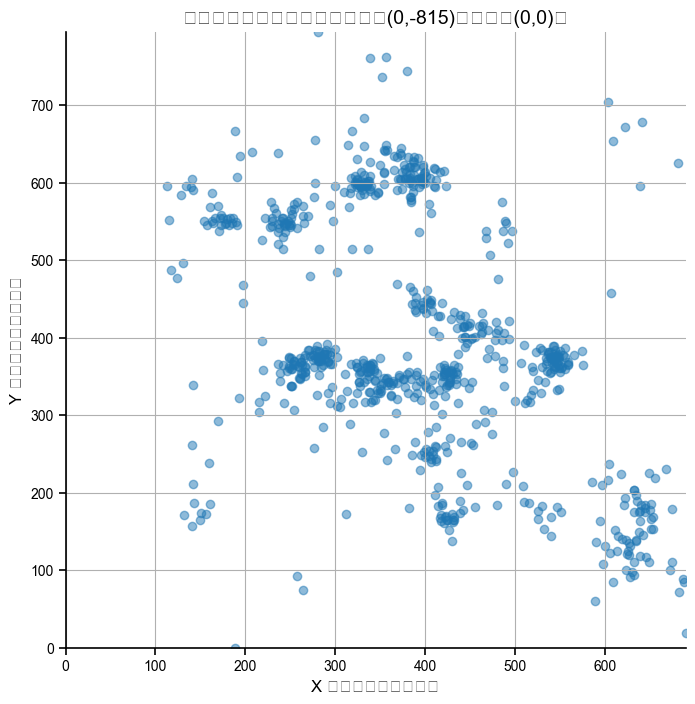

In [90]:
# 不再是将左下角实际点变为(0,0)，
# 而是将左下边界(0, -815)映射为(0, 0)，其他点相应变化（即 y_new = y_old + 815 ）
# X坐标不需调整，Y坐标整体加815

points_df_moved = points_df.copy()
points_df_moved['X坐标'] = points_df_moved['X坐标']
points_df_moved['Y坐标(已反转)'] = points_df_moved['Y坐标(已反转)'] + 815

display(points_df_moved)

plt.figure(figsize=(8,8))
plt.scatter(points_df_moved['X坐标'], points_df_moved['Y坐标(已反转)'], alpha=0.5)
plt.title('所有答卷点的分布（左下角边界(0,-815)已对齐为(0,0)）')
plt.xlabel('X 坐标（边界平移后）')
plt.ylabel('Y 坐标（边界平移后）')
plt.xlim(0, points_df_moved['X坐标'].max())
plt.ylim(0, points_df_moved['Y坐标(已反转)'].max())
plt.grid(True)
plt.show()


c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


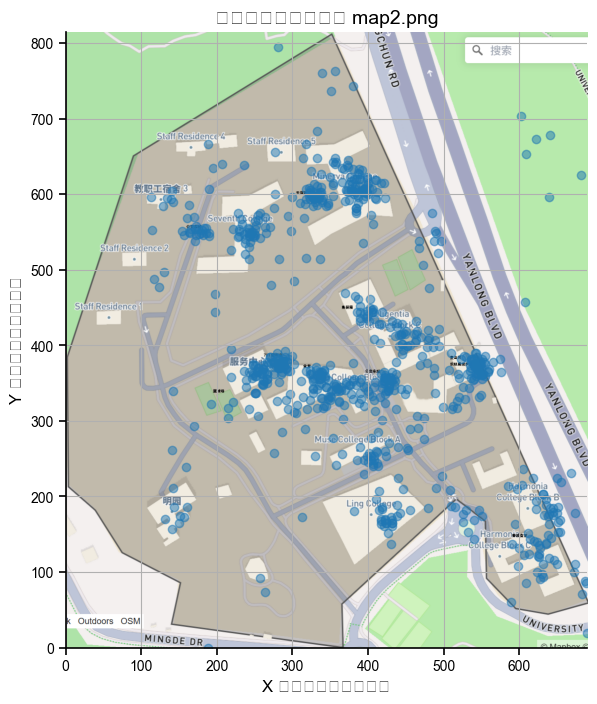

In [91]:
import matplotlib.image as mpimg

# 叠加map2.png作为背景
img = mpimg.imread('map2.png')

fig, ax = plt.subplots(figsize=(8,8))
# 直接按照图片坐标显示，不再设置origin='lower'
ax.imshow(img, extent=[0, 690, 0, 815])  # 默认origin='upper'，和图片坐标一致
ax.scatter(points_df_moved['X坐标'], points_df_moved['Y坐标(已反转)'], alpha=0.5)
ax.set_title('所有答卷点分布叠加 map2.png')
ax.set_xlabel('X 坐标（边界平移后）')
ax.set_ylabel('Y 坐标（边界平移后）')
ax.set_xlim(0, 690)
ax.set_ylim(0, 815)
ax.grid(True)
plt.show()


In [92]:
import matplotlib.pyplot as plt

In [93]:
import json

# 读取geojson的polygon边界
with open('boan.geojson', encoding='utf-8') as f:
    gj = json.load(f)

polygon_coords = gj['features'][0]['geometry']['coordinates'][0]
polygon_coords


[[274.8238772471668, 636.6110108552966],
 [68.55423053004779, 509.9618258611299],
 [0.0, 301.14927557716146],
 [1.330201282806229, 166.63535179710016],
 [29.350446722412016, 142.31745650421362],
 [57.394868236151524, 98.28596834593918],
 [118.07963970582932, 67.05030827375595],
 [108.80198009684682, 24.132630401989445],
 [287.2732299035415, 0.0],
 [286.0510435543838, 45.22412030631676],
 [404.8761259599705, 154.37629049178213],
 [435.22809623280773, 131.22159224026836],
 [436.46801607875386, 72.08220651524607],
 [466.8303065394284, 40.810054092668],
 [500.6596932657412, 35.05412503425032],
 [542.6313022772665, 46.702911492902786],
 [274.8238772471668, 636.6110108552966]]

c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


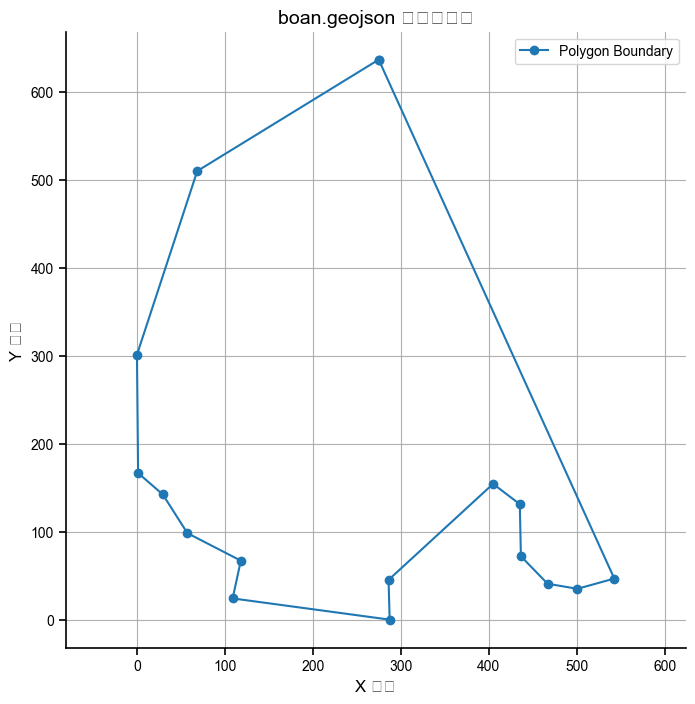

In [94]:
# 可视化 polygon_coords
import matplotlib.pyplot as plt

# 提取X和Y坐标
polygon_x = [pt[0] for pt in polygon_coords]
polygon_y = [pt[1] for pt in polygon_coords]

plt.figure(figsize=(8,8))
plt.plot(polygon_x, polygon_y, '-o', label='Polygon Boundary')
plt.title('boan.geojson 边界可视化')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


In [95]:
# 输出 polygon 的外框四个点（左下，左上，右上，右下）
import numpy as np

polygon_array = np.array(polygon_coords)
min_x = np.min(polygon_array[:,0])
max_x = np.max(polygon_array[:,0])
min_y = np.min(polygon_array[:,1])
max_y = np.max(polygon_array[:,1])

corner_points = [
    (min_x, min_y),  # 左下
    (min_x, max_y),  # 左上
    (max_x, max_y),  # 右上
    (max_x, min_y),  # 右下
]

print("Polygon 外框四个点为（左下、左上、右上、右下）：")
for i, pt in enumerate(corner_points, 1):
    print(f"{i}: {pt}")



Polygon 外框四个点为（左下、左上、右上、右下）：
1: (0.0, 0.0)
2: (0.0, 636.6110108552966)
3: (542.6313022772665, 636.6110108552966)
4: (542.6313022772665, 0.0)


c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21450 (\N{CJK UNIFIED IDEOGRAPH-53CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26694 (\N{CJK UNIFIED IDEOGRAPH-6846}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

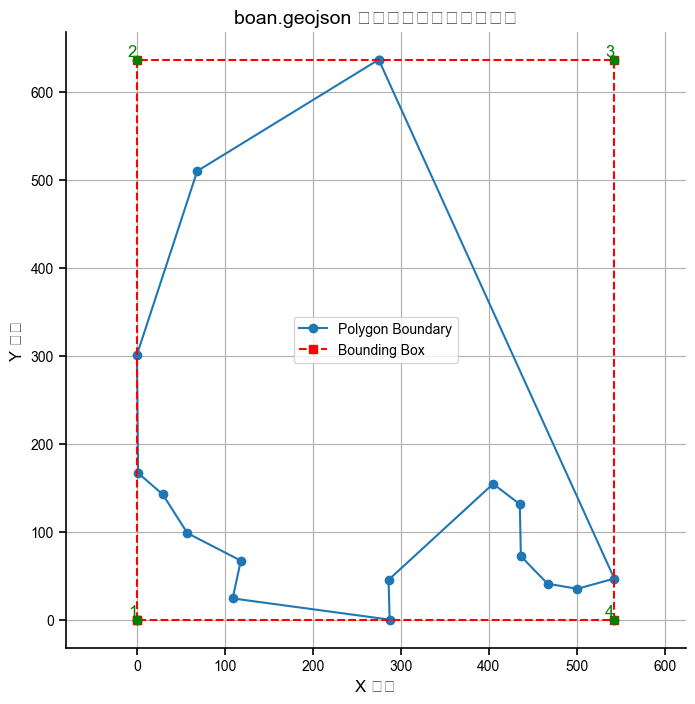

In [96]:
plt.figure(figsize=(8,8))

# 绘制polygon边界
plt.plot(polygon_x, polygon_y, '-o', label='Polygon Boundary')

# 绘制外框四个点连成的矩形
corner_x = [pt[0] for pt in corner_points] + [corner_points[0][0]]
corner_y = [pt[1] for pt in corner_points] + [corner_points[0][1]]
plt.plot(corner_x, corner_y, '--s', color='red', label='Bounding Box')

# 标记四个角点
for idx, pt in enumerate(corner_points, 1):
    plt.scatter(pt[0], pt[1], color='green', zorder=5)
    plt.text(pt[0], pt[1], f'{idx}', fontsize=12, color='green', verticalalignment='bottom', horizontalalignment='right')

plt.title('boan.geojson 边界及外框四个点可视化')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


In [97]:
points_df_moved

,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,622.290640
1,1,310.344828,588.165025
2,1,349.655172,622.290640
3,1,333.103448,317.167488
4,1,318.620690,666.453202
...,...,...,...
741,133,424.137931,252.931034
742,133,257.586207,541.995074
743,133,353.793103,598.201970
744,133,481.034483,475.751232


In [98]:
# 将points_df_moved中的点按原边框映射到boan.geojson外框对应的边框
# 假设points_df_moved存在，其包含"X坐标"、"Y坐标(已反转)"两列
# 原边框坐标（之前的坐标体系）
orig_min_x = 0
orig_max_x = 690
orig_min_y = 0
orig_max_y = 815

# 目标边框坐标，即boan.geojson外框
target_min_x, target_min_y = min_x, min_y
target_max_x, target_max_y = max_x, max_y

# 线性缩放映射函数
def map_point(x, y):
    # 防止零除和边界重叠问题
    if orig_max_x == orig_min_x:
        tx = target_min_x
    else:
        tx = (x - orig_min_x) / (orig_max_x - orig_min_x) * (target_max_x - target_min_x) + target_min_x
    if orig_max_y == orig_min_y:
        ty = target_min_y
    else:
        ty = (y - orig_min_y) / (orig_max_y - orig_min_y) * (target_max_y - target_min_y) + target_min_y
    return tx, ty

# 应用到所有点
mapped_points = points_df_moved.apply(lambda row: map_point(row['X坐标'], row['Y坐标(已反转)']), axis=1)
points_df_moved[['映射后_X坐标', '映射后_Y坐标']] = pd.DataFrame(mapped_points.tolist(), index=points_df_moved.index)

# 输出point_final
point_final = points_df_moved.copy()
# 你可以选取你需要的列，如下面只保留答卷序号和映射后的坐标
point_final = point_final[['答卷序号', '映射后_X坐标', '映射后_Y坐标']]




In [99]:
point_final

,答卷序号,映射后_X坐标,映射后_Y坐标
0,1,296.128627,486.082299
1,1,244.062055,459.426173
2,1,274.976582,486.082299
3,1,261.959939,247.745172
4,1,250.570376,520.578462
...,...,...,...
741,133,333.551475,197.568934
742,133,202.571506,423.362002
743,133,278.230743,467.266210
744,133,378.296185,371.617758


In [100]:
orig_min_x

0

c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26144 (\N{CJK UNIFIED IDEOGRAPH-6620}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

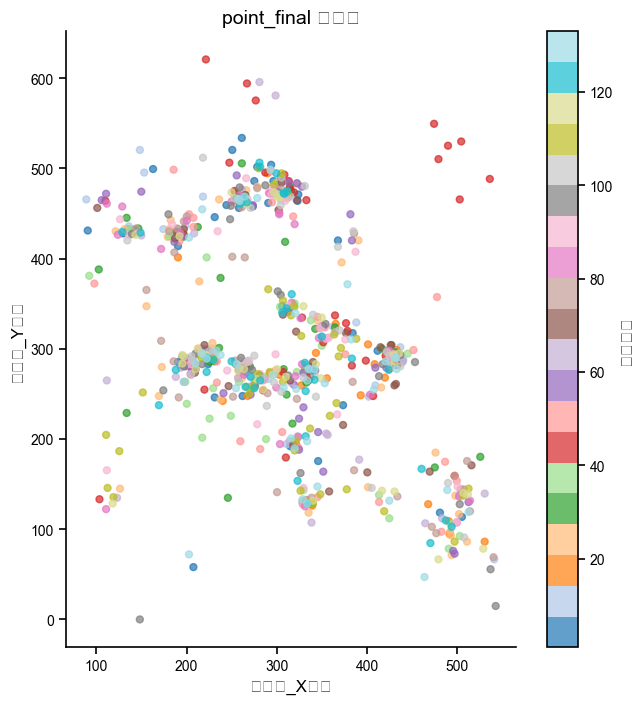

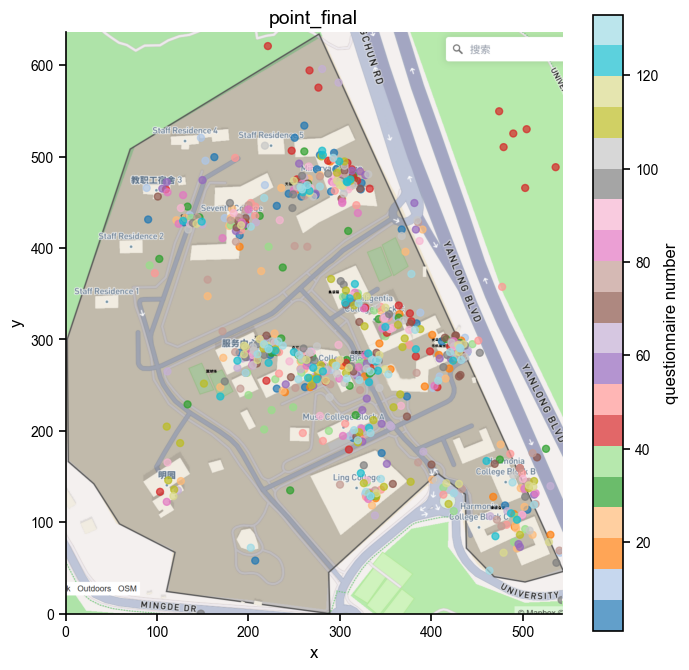

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
# 绘制所有答卷的点，按答卷序号上色
scatter = plt.scatter(point_final['映射后_X坐标'], point_final['映射后_Y坐标'],
                     c=point_final['答卷序号'], cmap='tab20', s=25, alpha=0.7)
plt.xlabel('映射后_X坐标')
plt.ylabel('映射后_Y坐标')
plt.title('point_final 可视化')
plt.colorbar(scatter, label='答卷序号')
plt.gca().set_aspect('equal')
plt.show()
# 在散点图下方叠加map2.png底图

import matplotlib.image as mpimg

# 读取底图
img = mpimg.imread('map2.png')

# 获取底图的显示范围（与target_min/max对应）
extent = [target_min_x, target_max_x, target_min_y, target_max_y]

plt.figure(figsize=(8, 8))
plt.imshow(img, extent=extent, origin='upper')  # origin='upper'确保图片方向与映射一致

# 绘制所有答卷的点，按答卷序号上色
scatter = plt.scatter(point_final['映射后_X坐标'], point_final['映射后_Y坐标'],
                     c=point_final['答卷序号'], cmap='tab20', s=25, alpha=0.7)

plt.xlabel('x')
plt.ylabel('y')
plt.title('point_final')
plt.colorbar(scatter, label='questionnaire number')
plt.gca().set_aspect('equal')
plt.show()


我需要进行有效的数据筛选。

我现在在思考如何处理一些明显不合理的数据。把数据给剔除了

是要聚合一些点的数据吗？

In [102]:
# 必要库
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 读取数据（如果你 notebook 里已有 point_final 变量，可跳过CSV读取，直接用它）
csv_path = 'point_final.csv'  # 或者直接用已有的 point_final DataFrame
df = pd.read_csv(csv_path, encoding='utf-8-sig')  # 列: ['答卷序号','映射后_X坐标','映射后_Y坐标']

# 2) 读取边界 polygon（boan.geojson）
with open('boan.geojson', encoding='utf-8') as f:
    gj = json.load(f)
polygon_coords = gj['features'][0]['geometry']['coordinates'][0]  # 外环

# 3) 基于边界筛点（含边界上的点）
# 优先用 shapely；如未安装则回退到 matplotlib.path
try:
    from shapely.geometry import Point, Polygon
    poly = Polygon(polygon_coords).buffer(0)  # buffer(0) 修复可能的自交/方向问题
    mask = [poly.covers(Point(x, y)) for x, y in zip(df['映射后_X坐标'], df['映射后_Y坐标'])]
except Exception:
    from matplotlib.path import Path
    poly_path = Path(polygon_coords)
    pts = np.column_stack([df['映射后_X坐标'].to_numpy(), df['映射后_Y坐标'].to_numpy()])
    # radius 轻微负值，尽量将边界点纳入
    mask = poly_path.contains_points(pts, radius=-1e-9)

df_in = df.loc[mask].reset_index(drop=True)

# 4) 为“同一答卷内，越靠前的点击权重越大”生成样本权重
# 使用文件出现顺序作为每份答卷的点击顺序；你若有更准确的点击时间戳，可替换这里的顺序依据
decay = 0.8  # 衰减系数（0.6~0.9常用，越小越强调前几次点击）
df_in['_seq'] = df_in.groupby('答卷序号').cumcount() + 1
df_in['sample_weight'] = decay ** (df_in['_seq'] - 1)

# 5) 聚类方案A（默认且无需装额外库）：GaussianMixture + BIC自动选簇数（加权）
from sklearn.mixture import GaussianMixture

X = df_in[['映射后_X坐标', '映射后_Y坐标']].to_numpy()
w = df_in['sample_weight'].to_numpy()

# 为了“尽量少”，只在较小k范围内搜索；可按需调大
candidate_ks = list(range(2, min(9, max(3, len(df_in)//80 + 3))))  # 2~8(或随样本数略放宽)
models, bics = [], []
for k in candidate_ks:
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gm.fit(X, sample_weight=w)
    bics.append(gm.bic(X))  # BIC基于当前模型评估
    models.append(gm)

best_idx = int(np.argmin(bics))
best_k = candidate_ks[best_idx]
best_model = models[best_idx]
labels = best_model.predict(X)
centers = best_model.means_

df_in['cluster'] = labels

print(f'[GMM] 选定簇数: {best_k}, BIC: {bics[best_idx]:.2f}')
print(df_in.groupby('cluster').size().rename('count').to_frame())
print('\n各簇中心(映射坐标系):')
print(pd.DataFrame(centers, columns=['cx','cy']).assign(cluster=range(best_k)))

# 6) 可选：聚类方案B（HDBSCAN，自带噪声识别&自动簇数，若已安装可尝试）
# import hdbscan
# clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, cluster_selection_epsilon=3)
# clusterer.fit(X, sample_weight=w)
# labels_hdb = clusterer.labels_
# df_in['cluster_hdb'] = labels_hdb
# print('HDBSCAN 簇数(不含噪声-1):', len(set(labels_hdb) - {-1}))

# 7) 保存结果
out_csv = 'point_clustered.csv'
df_in[['答卷序号','映射后_X坐标','映射后_Y坐标','sample_weight','cluster']].to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'已保存聚类结果到: {out_csv}')

# 8) 可视化（边界 + 聚类结果）
plt.figure(figsize=(8,8))
px, py = zip(*polygon_coords)
plt.plot(px, py, '-k', lw=1.2, label='boundary')

sc = plt.scatter(df_in['映射后_X坐标'], df_in['映射后_Y坐标'],
                 c=df_in['cluster'], cmap='tab10', s=14, alpha=0.8)
plt.colorbar(sc, label='cluster')

# 画GMM中心
plt.scatter(centers[:,0], centers[:,1], c='red', s=80, marker='X', label='centroid')

plt.gca().set_aspect('equal')
plt.title(f'Filtered in-boundary points + GMM clustering (k={best_k})')
plt.legend()
plt.show()

TypeError: BaseMixture.fit() got an unexpected keyword argument 'sample_weight'

[GMM] 模式: expanded, 选定簇数: 28, BIC: 48363.07
         count
cluster       
0           21
1           41
2           29
3           11
4           30
5            7
6           49
7           38
8           18
9           11
10          39
11          24
12          18
13          20
14          45
15          41
16          61
17          30
18          13
19           4
20           5
21          25
22           9
23           6
24          30
25          36
26           2
27          17

各簇中心(映射坐标系):
            cx          cy  cluster
0   334.193221  131.365054        0
1   259.112858  465.763632        1
2   337.240795  274.285823        2
3   208.725781  248.601399        3
4   489.934166   93.317648        4
5   106.115731  463.742650        5
6   266.787386  271.780438        6
7   426.259551  288.974996        7
8   277.977147  494.756549        8
9   118.525429  163.375524        9
10  191.759449  430.031433       10
11  315.521379  343.645862       11
12  223.827288  245.9434

c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yuyuio\anaconda3\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

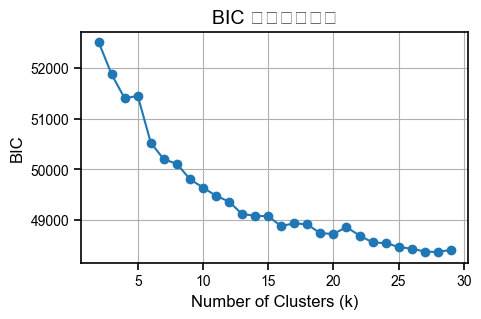

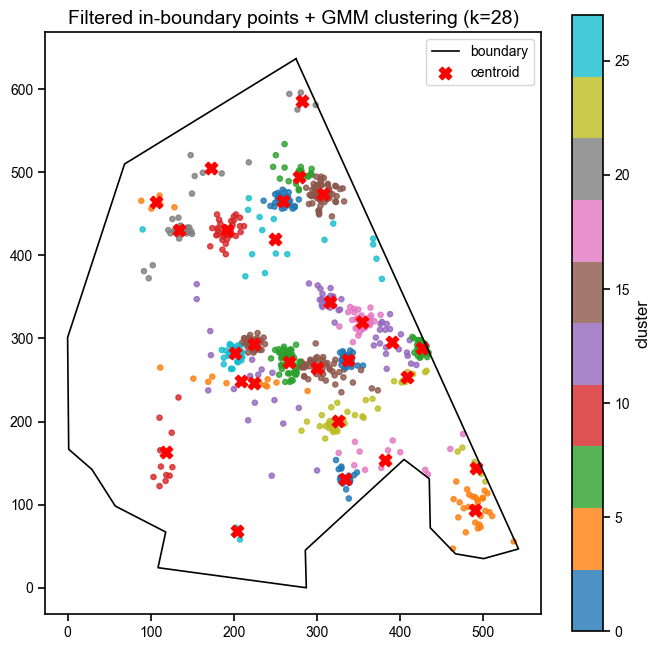

In [ ]:
# 5) 聚类方案A（兼容旧版sklearn）：GaussianMixture + BIC 自动选簇数（带权重/扩样回退）
from sklearn.mixture import GaussianMixture
import inspect
import matplotlib.pyplot as plt

X = df_in[['映射后_X坐标', '映射后_Y坐标']].to_numpy()
w = df_in['sample_weight'].to_numpy()

# 为了“尽量少簇”，可适当收紧搜索范围
candidate_ks = list(range(2, 30)  )# 2~8

def fit_gmm_auto(X, w, candidate_ks, random_state=42):
    # 判断是否原生支持 sample_weight
    try:
        supports_weight = ('sample_weight' in inspect.signature(GaussianMixture.fit).parameters)
    except Exception:
        supports_weight = False

    models, bics = [], []
    mode = 'native' if supports_weight else 'expanded'

    if supports_weight:
        for k in candidate_ks:
            gm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gm.fit(X, sample_weight=w)
            bics.append(gm.bic(X))
            models.append(gm)
    else:
        # 回退：按权重扩样（避免数据量爆炸，映射到1~5次）
        w_norm = w / w.max() if w.max() > 0 else w
        reps = np.clip(np.round(5 * w_norm), 1, 5).astype(int)  # 想更强调权重，可把5调大
        X_rep = np.repeat(X, reps, axis=0)
        for k in candidate_ks:
            gm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gm.fit(X_rep)
            bics.append(gm.bic(X_rep))
            models.append(gm)

    best_idx = int(np.argmin(bics))
    best_k = candidate_ks[best_idx]
    best_model = models[best_idx]
    labels = best_model.predict(X)         # 在原始样本上出预测
    centers = best_model.means_
    return best_k, best_model, labels, centers, bics[best_idx], mode, bics, models

best_k, best_model, labels, centers, best_bic, mode, bics, models = fit_gmm_auto(X, w, candidate_ks)
df_in['cluster'] = labels

print(f'[GMM] 模式: {mode}, 选定簇数: {best_k}, BIC: {best_bic:.2f}')
print(df_in.groupby('cluster').size().rename('count').to_frame())
print('\n各簇中心(映射坐标系):')
print(pd.DataFrame(centers, columns=['cx','cy']).assign(cluster=range(best_k)))

# ---- 可视化部分 ----
# 可视化不同k下的BIC
plt.figure(figsize=(5, 3))
plt.plot(candidate_ks, bics, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("BIC")
plt.title("BIC 值随簇数变化")
plt.grid(True)
plt.show()

# 可视化聚类结果
plt.figure(figsize=(8,8))
# 建议提前准备 polygon_coords 边界（如：polygon_coords = [[...], ...]）
try:
    px, py = zip(*polygon_coords)
    plt.plot(px, py, '-k', lw=1.2, label='boundary')
except Exception:
    pass

sc = plt.scatter(df_in['映射后_X坐标'], df_in['映射后_Y坐标'],
                 c=df_in['cluster'], cmap='tab10', s=14, alpha=0.8)
plt.colorbar(sc, label='cluster')

# 画GMM中心
plt.scatter(centers[:,0], centers[:,1], c='red', s=80, marker='X', label='centroid')

plt.gca().set_aspect('equal')
plt.title(f'Filtered in-boundary points + GMM clustering (k={best_k})')
plt.legend()
plt.show()

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import os
from sklearn.mixture import GaussianMixture
import inspect

# 设置 matplotlib 为学术发表模式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

def fit_gmm_auto(X, w, candidate_ks, random_state=42):
    """GMM 自动选择簇数（带权重支持）"""
    try:
        supports_weight = ('sample_weight' in inspect.signature(GaussianMixture.fit).parameters)
    except Exception:
        supports_weight = False

    models, bics = [], []
    mode = 'native' if supports_weight else 'expanded'

    if supports_weight:
        for k in candidate_ks:
            gm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gm.fit(X, sample_weight=w)
            bics.append(gm.bic(X))
            models.append(gm)
    else:
        w_norm = w / w.max() if w.max() > 0 else w
        reps = np.clip(np.round(5 * w_norm), 1, 5).astype(int)
        X_rep = np.repeat(X, reps, axis=0)
        for k in candidate_ks:
            gm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gm.fit(X_rep)
            bics.append(gm.bic(X_rep))
            models.append(gm)

    best_idx = int(np.argmin(bics))
    best_k = candidate_ks[best_idx]
    best_model = models[best_idx]
    labels = best_model.predict(X)
    centers = best_model.means_
    return best_k, best_model, labels, centers, bics[best_idx], mode, bics, models

def plot_publication_clustering(df_in, polygon_coords, centers, labels, best_k, best_bic,
                                output_path=None, dpi=300, save_format='pdf'):
    """
    学术发表级别的聚类可视化
    
    参数:
    - df_in: 包含聚类结果的 DataFrame
    - polygon_coords: 边界坐标列表
    - centers: 聚类中心数组
    - labels: 聚类标签数组
    - best_k: 最优簇数
    - best_bic: 最优 BIC 值
    - output_path: 保存路径（如果为 None 则只显示）
    - dpi: 分辨率
    - save_format: 保存格式
    """
    # 创建图形
    fig_width = 7.0
    fig_height = 6.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi, facecolor='white')

    # 1. 绘制边界（最底层）
    if polygon_coords:
        boundary_coords = np.array(polygon_coords)
        # 边界填充（浅灰色底图）
        boundary_poly = Polygon(boundary_coords, closed=True,
                               facecolor='#f5f5f5',
                               alpha=0.3,
                               edgecolor='none',
                               zorder=0)
        ax.add_patch(boundary_poly)
        
        # 边界线（黑色）
        ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
               color='black', linewidth=1.5, zorder=3)

    # 2. 绘制聚类点（使用更专业的颜色方案）
    # 使用色盲友好的颜色方案
    scatter = ax.scatter(df_in['映射后_X坐标'], df_in['映射后_Y坐标'],
                        c=labels, 
                        cmap='tab10',  # 或使用 'Set3', 'Paired' 等
                        s=20,  # 稍小的点
                        alpha=0.7,
                        edgecolors='white',  # 白色边框，更清晰
                        linewidths=0.3,
                        zorder=2)

    # 3. 绘制聚类中心（更专业的样式）
    ax.scatter(centers[:, 0], centers[:, 1], 
              c='red', 
              s=120,  # 更大的标记
              marker='X',  # X 标记
              edgecolors='darkred', 
              linewidths=1.5,
              label='Cluster Centers',
              zorder=4)

    # 4. 设置坐标轴
    ax.set_xlabel('X Coordinate (m)', fontsize=12, fontweight='normal')
    ax.set_ylabel('Y Coordinate (m)', fontsize=12, fontweight='normal')
    
    # 设置刻度
    ax.tick_params(axis='both', which='major', length=5, width=1.2)
    ax.tick_params(axis='both', which='minor', length=3, width=1.0)
    
    # 设置等比例
    ax.set_aspect('equal')

    # 5. 颜色条（更专业的样式）
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Cluster ID', fontsize=11, fontweight='normal', rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=10, width=1.2, length=5)

    # 6. 图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=1.5, label='Campus Boundary'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='red', 
               markeredgecolor='darkred', markersize=10, markeredgewidth=1.5,
               label='Cluster Centers')
    ]
    ax.legend(handles=legend_elements, loc='upper right',
             frameon=True, fancybox=False, shadow=False,
             framealpha=0.9, edgecolor='gray', facecolor='white')

    # 7. 移除不必要的元素
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.grid(False)

    # 8. 调整布局
    plt.tight_layout()
    
    # 9. 保存或显示
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.1)
        print(f"已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    
    plt.close()

# --- 执行：生成发表级别的聚类图 ---
# 注意：这里假设 df_in, polygon_coords, centers, labels, best_k, best_bic 已经存在
# 如果还没有运行聚类代码，需要先运行前面的 cell

base_path = r"D:\progamming\python_script\Social-physical-system-shelter"

# 检查必要的变量是否存在
try:
    # 如果变量存在，直接使用
    if 'df_in' in globals() and 'polygon_coords' in globals() and 'centers' in globals():
        # 生成高分辨率 PDF
        output_pdf = os.path.join(base_path, "data_empirical", "gmm_clustering_publication.svg")
        plot_publication_clustering(
            df_in, polygon_coords, centers, labels, best_k, best_bic,
            output_path=output_pdf,
            dpi=300,
            save_format='svg'
        )
        
        # 生成高分辨率 PNG
        output_png = os.path.join(base_path, "data_empirical", "gmm_clustering_publication.png")
        plot_publication_clustering(
            df_in, polygon_coords, centers, labels, best_k, best_bic,
            output_path=output_png,
            dpi=600,
            save_format='png'
        )
    else:
        print("提示：请先运行聚类代码（前面的 cell），确保以下变量存在：")
        print("  - df_in: 包含聚类结果的 DataFrame")
        print("  - polygon_coords: 边界坐标")
        print("  - centers: 聚类中心")
        print("  - labels: 聚类标签")
        print("  - best_k: 最优簇数")
        print("  - best_bic: 最优 BIC 值")
except NameError as e:
    print(f"变量未定义: {e}")
    print("请先运行前面的聚类代码 cell")


已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\gmm_clustering_publication.svg (DPI=300, 格式=svg)
已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\gmm_clustering_publication.png (DPI=600, 格式=png)


In [ ]:
import json

# 构造GeoJSON结构
geojson_centers = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"cluster": int(i)},
            "geometry": {
                "type": "Point",
                "coordinates": [float(cx), float(cy)]
            }
        }
        for i, (cx, cy) in enumerate(centers)
    ]
}

# 输出为geojson文件
with open("gmm_centers.geojson", "w", encoding="utf-8") as f:
    json.dump(geojson_centers, f, ensure_ascii=False, indent=2)

print("已导出GMM聚类中心点为 geojson 文件: gmm_centers.geojson")

已导出GMM聚类中心点为 geojson 文件: gmm_centers.geojson


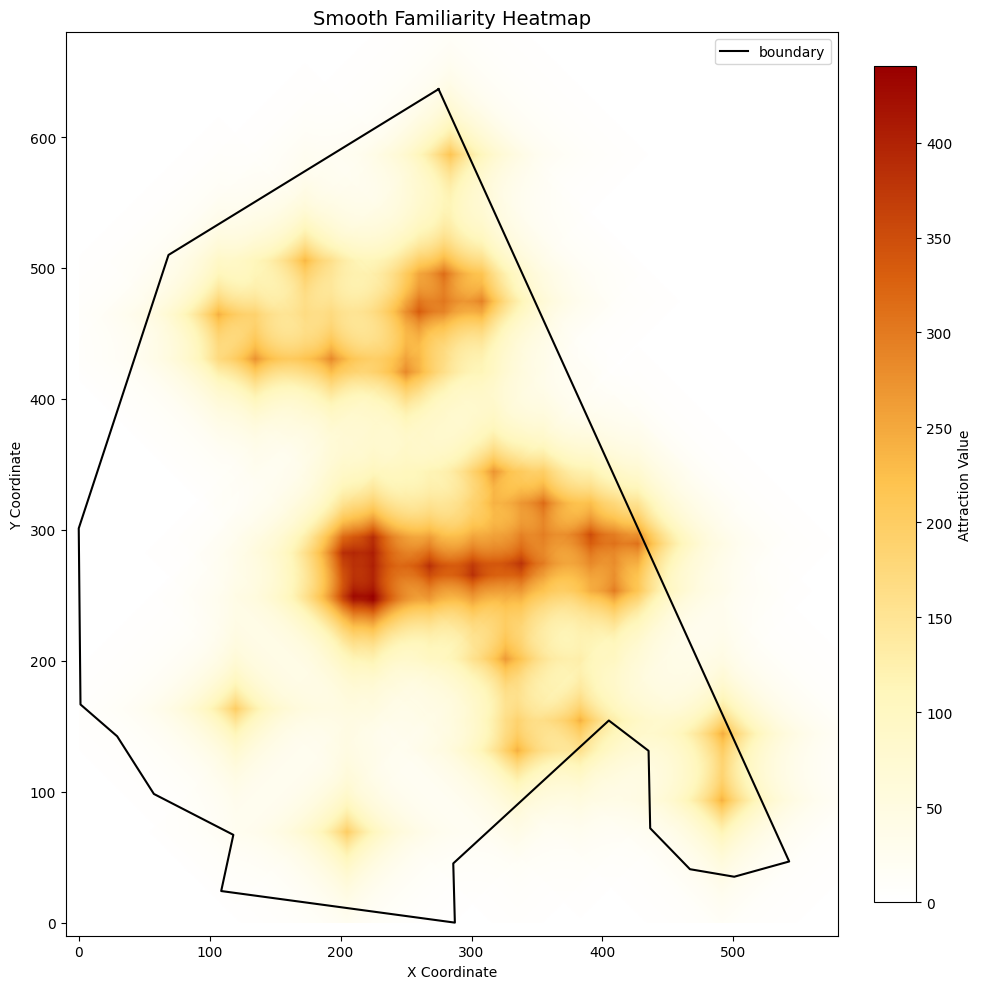

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_attraction_heatmap_smooth(json_path, boundary_path, grid_size=(700, 700)):
    """
    实现无缝融合的热力图：
    1. 自定义从白色开始的色带
    2. 使用双线性插值消除锯齿
    """
    if not os.path.exists(json_path):
        print(f"文件不存在: {json_path}")
        return

    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float) # 保持原始数值，不设为 NaN

    # 2. 【核心优化】创建自定义色带：从纯白 (#ffffff) 平滑过渡到热力色
    # 我们参考 YlOrRd 的配色，但把起点强制改为白色
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    # 3. 绘图配置
    plt.figure(figsize=(10, 10), facecolor='white')
    ax = plt.gca()

    # 4. 【关键参数】使用 interpolation='bilinear' 让边缘平滑模糊
    # vmin=0 确保 0 值准确对应色带开头的白色
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           # 强制从 0 开始渲染，使 0 值变为白色
        aspect='equal',
        interpolation='bilinear', # 开启双线性插值，消除锯齿
        alpha=1.0
    )

    # 5. 叠加边界 (加粗黑色线，更醒目)
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='boundary', zorder=3)

    # 6. 对齐坐标范围
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)

    # 7. 细节打磨
    plt.title("Smooth Familiarity Heatmap", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(loc='upper right')
    
    # 调整 colorbar
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Attraction Value')

    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_file = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")

plot_attraction_heatmap_smooth(target_file, boundary_file)

最大点值: 440.3522299416826
最大值所在坐标 (Y, X): (249, 224)  (对应画面定位)


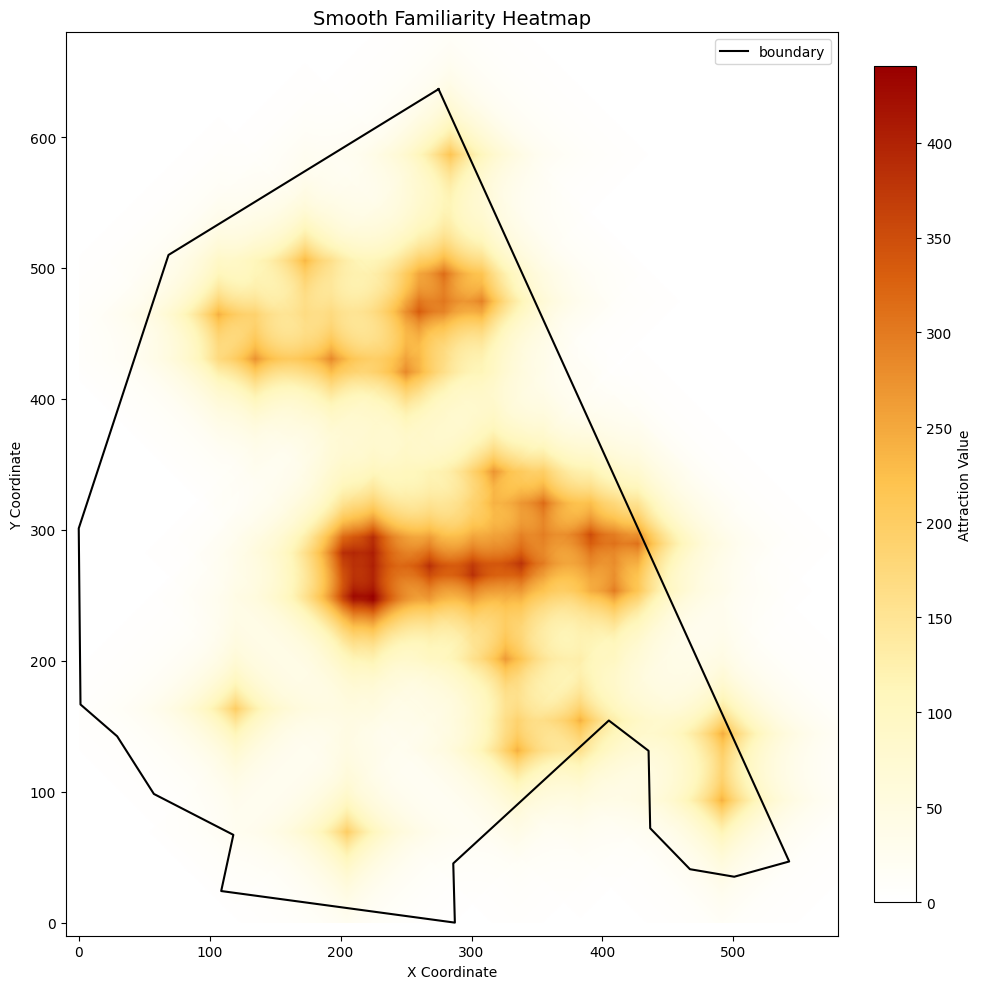

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_attraction_heatmap_smooth(json_path, boundary_path, grid_size=(700, 700)):
    """
    实现无缝融合的热力图：
    1. 自定义从白色开始的色带
    2. 使用双线性插值消除锯齿
    并输出最大吸引值点
    """
    if not os.path.exists(json_path):
        print(f"文件不存在: {json_path}")
        return

    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float) # 保持原始数值，不设为 NaN

    # 输出最大值
    max_value = np.max(matrix_plot)
    max_indices = np.unravel_index(np.argmax(matrix_plot), matrix_plot.shape)
    print(f"最大点值: {max_value}")
    print(f"最大值所在坐标 (Y, X): {max_indices}  (对应画面定位)")

    # 2. 【核心优化】创建自定义色带：从纯白 (#ffffff) 平滑过渡到热力色
    # 我们参考 YlOrRd 的配色，但把起点强制改为白色
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    # 3. 绘图配置
    plt.figure(figsize=(10, 10), facecolor='white')
    ax = plt.gca()

    # 4. 【关键参数】使用 interpolation='bilinear' 让边缘平滑模糊
    # vmin=0 确保 0 值准确对应色带开头的白色
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           # 强制从 0 开始渲染，使 0 值变为白色
        aspect='equal',
        interpolation='bilinear', # 开启双线性插值，消除锯齿
        alpha=1.0
    )

    # 5. 叠加边界 (加粗黑色线，更醒目)
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='boundary', zorder=3)

    # 6. 对齐坐标范围
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)

    # 7. 细节打磨
    plt.title("Smooth Familiarity Heatmap", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(loc='upper right')
    
    # 调整 colorbar
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Attraction Value')

    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_file = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")

plot_attraction_heatmap_smooth(target_file, boundary_file)

边界 mask 统计: 边界内点数=202305, 总点数=490000, 比例=41.29%
最大点值(平滑后): 0.993801
最大值所在坐标 (Y, X): (249, 222)  (对应画面定位)


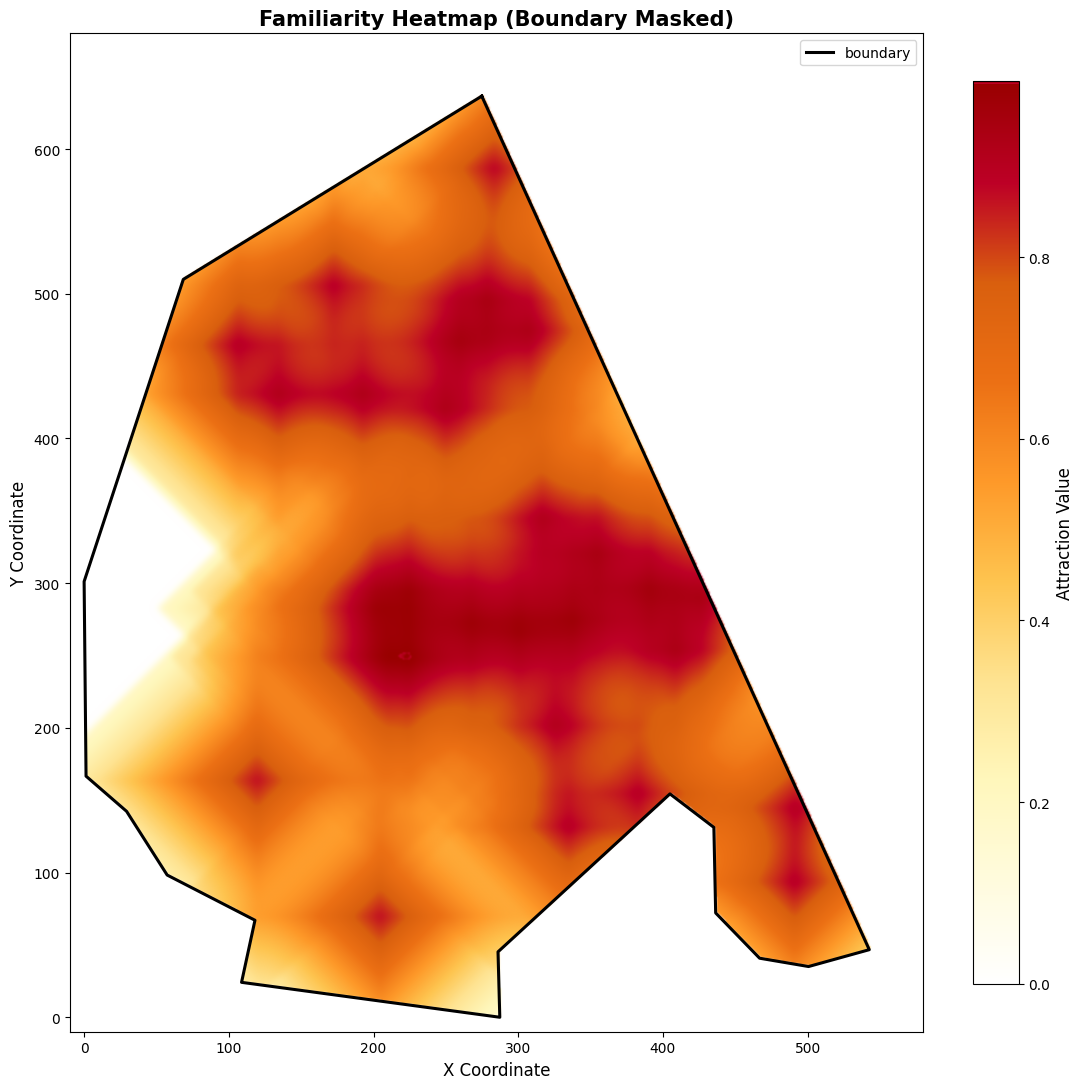

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import os
from scipy.ndimage import gaussian_filter

def get_smooth_colormap():
    # 重点：使用from_list容易在白色到第一种颜色不够平滑，改用LinearSegmentedColormap的分段渐变
    # 利用numpy插值，让白色到浅黄色过渡非常平滑
    white = np.array(mcolors.to_rgb("#ffffff"))
    light_yellow = np.array(mcolors.to_rgb("#fff7bc"))
    yellow = np.array(mcolors.to_rgb("#fee391"))
    orange = np.array(mcolors.to_rgb("#fec44f"))
    orange2 = np.array(mcolors.to_rgb("#fe9929"))
    brown = np.array(mcolors.to_rgb("#ec7014"))
    dark_orange = np.array(mcolors.to_rgb("#d95f0e"))
    red = np.array(mcolors.to_rgb("#bd0026"))
    deep_red = np.array(mcolors.to_rgb("#990000"))

    # 线性插值让色带分布更均匀，特别是前段“白色到浅黄”部分拉长，使0值到较小值渐变更自然
    n_smooth_white = 230  # 白色与第一主色平滑过渡长度
    n_cmap = 1024
    c_array = np.zeros((n_cmap, 3))
    # 前段白色到亮黄
    for i in range(n_smooth_white):
        frac = i / (n_smooth_white-1)
        c_array[i] = (1-frac)*white + frac*light_yellow
    # 其余使用np.linspace做主色分段（除了前面已做的）
    key_colors = [
        light_yellow, yellow, orange, orange2, brown, dark_orange, red, deep_red
    ]
    segs = [n_smooth_white]
    for _ in range(len(key_colors)-1):
        segs.append( int((n_cmap-n_smooth_white)//(len(key_colors)-1)) )
    cumulative = n_smooth_white
    for k,(c1,c2,seg_len) in enumerate(zip(key_colors[:-1], key_colors[1:], segs[1:])):
        arr = np.linspace(c1, c2, seg_len, endpoint=False)
        c_array[cumulative:cumulative+seg_len,:] = arr
        cumulative += seg_len
    # 若剩余，再拉到最后一色
    if cumulative < n_cmap:
        arr = np.linspace(key_colors[-2], key_colors[-1], n_cmap-cumulative)
        c_array[cumulative:,:] = arr

    return mcolors.ListedColormap(c_array)

def create_boundary_mask(boundary_path, grid_size=(700, 700)):
    """
    创建边界 mask：边界内为 True，边界外为 False
    注意：边界坐标和网格坐标应该在同一坐标系下（都是 0-699）
    """
    if not os.path.exists(boundary_path):
        return None
    
    with open(boundary_path, 'r', encoding='utf-8') as f:
        boundary_data = json.load(f)
        feature = boundary_data['features'][0]
        boundary_coords = np.array(feature['geometry']['coordinates'][0])
    
    # 创建路径对象
    poly_path = mpath.Path(boundary_coords)
    
    # 创建网格坐标（与 imshow 的 extent 对应：[0, grid_size[0], 0, grid_size[1]]）
    x = np.arange(0, grid_size[0])
    y = np.arange(0, grid_size[1])
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])
    
    # 检查每个点是否在边界内
    # 使用 radius=0 进行严格判断（边界上的点会被包含）
    # 注意：如果边界附近显示白色，可能是因为原始数据值接近 0（这是正常的）
    mask = poly_path.contains_points(points, radius=0)
    mask = mask.reshape(grid_size[1], grid_size[0])  # 转置以匹配 matrix_plot 的形状
    
    return mask

def plot_attraction_heatmap_smooth(json_path, boundary_path, grid_size=(700, 700)):
    """
    热力图白色到其他颜色极为平滑的渐变
    1. 白色到主色平滑插值
    2. 高斯滤波进一步平滑数据
    3. 双三次插值显示
    输出最大吸引值点
    """
    if not os.path.exists(json_path):
        print(f"文件不存在: {json_path}")
        return

    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)  # 转置以匹配显示坐标

    # 创建边界 mask（边界内为 True，边界外为 False）
    boundary_mask = create_boundary_mask(boundary_path, grid_size)
    
    # 先应用高斯滤波（在应用 mask 之前，避免边界附近的平滑被截断）
    matrix_plot_smooth = gaussian_filter(matrix_plot, sigma=2.2)
    
    # 滤波后再应用边界 mask，将边界外的值设为 NaN（这样会显示为白色）
    if boundary_mask is not None:
        # 统计 mask 信息（用于调试）
        inside_count = np.sum(boundary_mask)
        total_count = boundary_mask.size
        print(f"边界 mask 统计: 边界内点数={inside_count}, 总点数={total_count}, 比例={inside_count/total_count:.2%}")
        
        matrix_plot_smooth[~boundary_mask] = np.nan
    else:
        print("警告: 无法创建边界 mask，将显示全部区域")

    # 输出最大值（只统计边界内的值）
    valid_data = matrix_plot_smooth[~np.isnan(matrix_plot_smooth)]
    if len(valid_data) > 0:
        max_value = np.max(valid_data)
        max_indices = np.unravel_index(np.nanargmax(matrix_plot_smooth), matrix_plot_smooth.shape)
        print(f"最大点值(平滑后): {max_value:.6f}")
        print(f"最大值所在坐标 (Y, X): {max_indices}  (对应画面定位)")

    # 2. 自定义色带：白色到主色极度平滑
    custom_cmap = get_smooth_colormap()
    # 设置 NaN 值的颜色为白色
    custom_cmap.set_bad(color='white', alpha=1.0)

    # 3. 绘图配置
    plt.figure(figsize=(11, 11), facecolor='white')
    ax = plt.gca()

    # 4. 用bicubic插值让界面平滑
    img = ax.imshow(
        matrix_plot_smooth, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           # 保证0为最白色
        aspect='equal',
        interpolation='bicubic',
        alpha=1.0
    )

    # 5. 叠加边界 (加粗黑色线)
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=2.2, label='boundary', zorder=3)

    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title("Familiarity Heatmap (Boundary Masked)", fontsize=15, fontweight='bold')
    plt.xlabel("X Coordinate", fontsize=12)
    plt.ylabel("Y Coordinate", fontsize=12)
    plt.legend(loc='upper right')
    cbar = plt.colorbar(img, fraction=0.045, pad=0.05)
    cbar.set_label('Attraction Value', fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_file = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points_normalized.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")

plot_attraction_heatmap_smooth(target_file, boundary_file)

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import os
from scipy.ndimage import gaussian_filter

# 设置 matplotlib 为学术发表模式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

def get_publication_colormap():
    """
    创建适合学术发表的色带：
    1. 色盲友好（使用 viridis 或类似的配色）
    2. 平滑过渡
    3. 适合黑白打印（可选）
    """
    # 方案1：使用 viridis 风格（色盲友好，适合发表）
    # 方案2：保持原有的白色到红色渐变，但优化平滑度
    
    # 这里使用方案2，但可以轻松切换到 viridis
    white = np.array(mcolors.to_rgb("#ffffff"))
    light_yellow = np.array(mcolors.to_rgb("#fff7bc"))
    yellow = np.array(mcolors.to_rgb("#fee391"))
    orange = np.array(mcolors.to_rgb("#fec44f"))
    orange2 = np.array(mcolors.to_rgb("#fe9929"))
    brown = np.array(mcolors.to_rgb("#ec7014"))
    dark_orange = np.array(mcolors.to_rgb("#d95f0e"))
    red = np.array(mcolors.to_rgb("#bd0026"))
    deep_red = np.array(mcolors.to_rgb("#990000"))

    # 增加白色到浅黄色的过渡长度
    n_smooth_white = 300
    n_cmap = 1024
    c_array = np.zeros((n_cmap, 3))
    
    # 前段白色到亮黄：使用平滑插值
    for i in range(n_smooth_white):
        frac = i / (n_smooth_white - 1)
        smooth_frac = frac * frac * (3 - 2 * frac)  # smoothstep
        c_array[i] = (1 - smooth_frac) * white + smooth_frac * light_yellow
    
    # 其余颜色分段
    key_colors = [
        light_yellow, yellow, orange, orange2, brown, dark_orange, red, deep_red
    ]
    segs = [n_smooth_white]
    for _ in range(len(key_colors) - 1):
        segs.append(int((n_cmap - n_smooth_white) // (len(key_colors) - 1)))
    cumulative = n_smooth_white
    for k, (c1, c2, seg_len) in enumerate(zip(key_colors[:-1], key_colors[1:], segs[1:])):
        arr = np.linspace(c1, c2, seg_len, endpoint=False)
        c_array[cumulative:cumulative + seg_len, :] = arr
        cumulative += seg_len
    if cumulative < n_cmap:
        arr = np.linspace(key_colors[-2], key_colors[-1], n_cmap - cumulative)
        c_array[cumulative:, :] = arr

    return mcolors.ListedColormap(c_array)

def create_boundary_mask(boundary_path, grid_size=(700, 700)):
    """创建边界 mask"""
    if not os.path.exists(boundary_path):
        return None
    
    with open(boundary_path, 'r', encoding='utf-8') as f:
        boundary_data = json.load(f)
        feature = boundary_data['features'][0]
        boundary_coords = np.array(feature['geometry']['coordinates'][0])
    
    poly_path = mpath.Path(boundary_coords)
    x = np.arange(0, grid_size[0])
    y = np.arange(0, grid_size[1])
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])
    mask = poly_path.contains_points(points, radius=0)
    mask = mask.reshape(grid_size[1], grid_size[0])
    
    return mask

def plot_publication_heatmap(json_path, boundary_path, output_path=None, 
                             grid_size=(700, 700), dpi=300, 
                             unit_label="Familiarity Value", 
                             save_format='pdf'):
    """
    学术发表级别的热力图
    
    参数:
    - output_path: 保存路径（如果为 None 则只显示）
    - dpi: 分辨率（期刊通常要求 300-600 DPI）
    - unit_label: 颜色条标签
    - save_format: 保存格式 ('pdf', 'png', 'eps', 'tiff')
    """
    if not os.path.exists(json_path):
        print(f"文件不存在: {json_path}")
        return

    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)

    # 2. 创建边界 mask
    boundary_mask = create_boundary_mask(boundary_path, grid_size)
    
    # 3. 高斯滤波
    matrix_plot_smooth = gaussian_filter(matrix_plot, sigma=2.2)
    
    # 4. 应用边界 mask
    if boundary_mask is not None:
        matrix_plot_smooth[~boundary_mask] = np.nan

    # 5. 创建色带
    custom_cmap = get_publication_colormap()
    custom_cmap.set_bad(color='white', alpha=1.0)

    # 6. 创建图形（学术发表通常使用单栏或双栏宽度）
    # 单栏宽度约 3.5 英寸，双栏约 7 英寸
    fig_width = 6.5  # 适合双栏或大图
    fig_height = 6.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi, facecolor='white')
    
    # 7. 绘制热力图
    img = ax.imshow(
        matrix_plot_smooth, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,
        vmax=1.0,  # 归一化后的最大值
        aspect='equal',
        interpolation='bicubic',
        alpha=1.0
    )

    # 8. 绘制边界（更细的线条，更专业）
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                   color='black', linewidth=1.5, zorder=3)

    # 9. 设置坐标轴（更专业的标签）
    ax.set_xlim(-10, 580)
    ax.set_ylim(-10, 680)
    ax.set_xlabel('X Coordinate (m)', fontsize=12, fontweight='normal')
    ax.set_ylabel('Y Coordinate (m)', fontsize=12, fontweight='normal')
    
    # 设置刻度
    ax.tick_params(axis='both', which='major', length=5, width=1.2)
    ax.tick_params(axis='both', which='minor', length=3, width=1.0)
    
    # 10. 颜色条（更专业的样式）
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04, 
                       ticks=np.linspace(0, 1.0, 6))
    cbar.set_label(unit_label, fontsize=11, fontweight='normal', rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=10, width=1.2, length=5)
    
    # 11. 移除不必要的元素
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # 12. 调整布局
    plt.tight_layout()
    
    # 13. 保存或显示
    if output_path:
        # 确保目录存在
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.1)
        print(f"已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    
    plt.close()

# --- 执行：生成发表级别的图片 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_file = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points_normalized.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")

# 生成高分辨率图片（PDF 格式适合发表）
output_pdf = os.path.join(base_path, "data_empirical", "familiarity_heatmap_publication.pdf")
plot_publication_heatmap(
    target_file, 
    boundary_file, 
    output_path=output_pdf,
    dpi=300,
    unit_label="Normalized Familiarity Value",
    save_format='pdf'
)

# 也可以生成 PNG 格式（用于预览或某些期刊要求）
output_png = os.path.join(base_path, "data_empirical", "familiarity_heatmap_publication.png")
plot_publication_heatmap(
    target_file, 
    boundary_file, 
    output_path=output_png,
    dpi=600,  # PNG 通常需要更高 DPI
    unit_label="Normalized Familiarity Value",
    save_format='png'
)


已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\familiarity_heatmap_publication.pdf (DPI=300, 格式=pdf)
已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\familiarity_heatmap_publication.png (DPI=600, 格式=png)


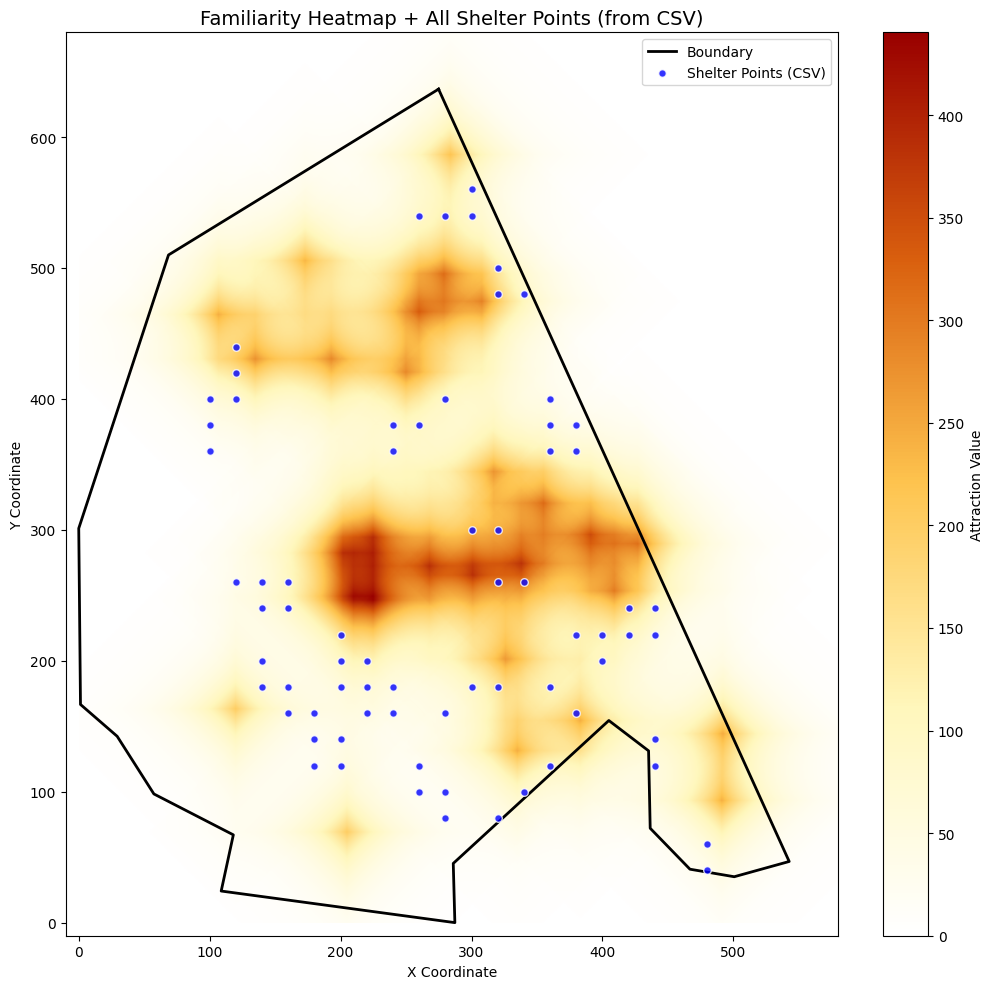

In [ ]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_shelter_csv(json_path, boundary_path, csv_path, grid_size=(700, 700)):
    # 1. 加载熟悉度热力图数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)

    # 2. 加载 CSV 坐标点
    shelter_df = pd.read_csv(csv_path)

    # 3. 创建自定义色带
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    # 4. 绘图
    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 绘制热力图底图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=1.0,
        zorder=1
    )

    # 5. 叠加边界线
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=2, label='Boundary', zorder=3)

    # 6. 【核心步骤】叠加 CSV 中的 71 个避难所坐标点
    plt.scatter(
        shelter_df['x'], 
        shelter_df['y'], 
        c='blue', 
        s=30, 
        marker='o', 
        edgecolors='white', 
        label='Shelter Points (CSV)', 
        zorder=4,
        alpha=0.8
    )

    # 7. 设置坐标范围与细节
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title("Familiarity Heatmap + All Shelter Points (from CSV)", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Attraction Value')

    plt.legend(loc='upper right')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_shelter_csv(target_json, boundary_file, csv_file)

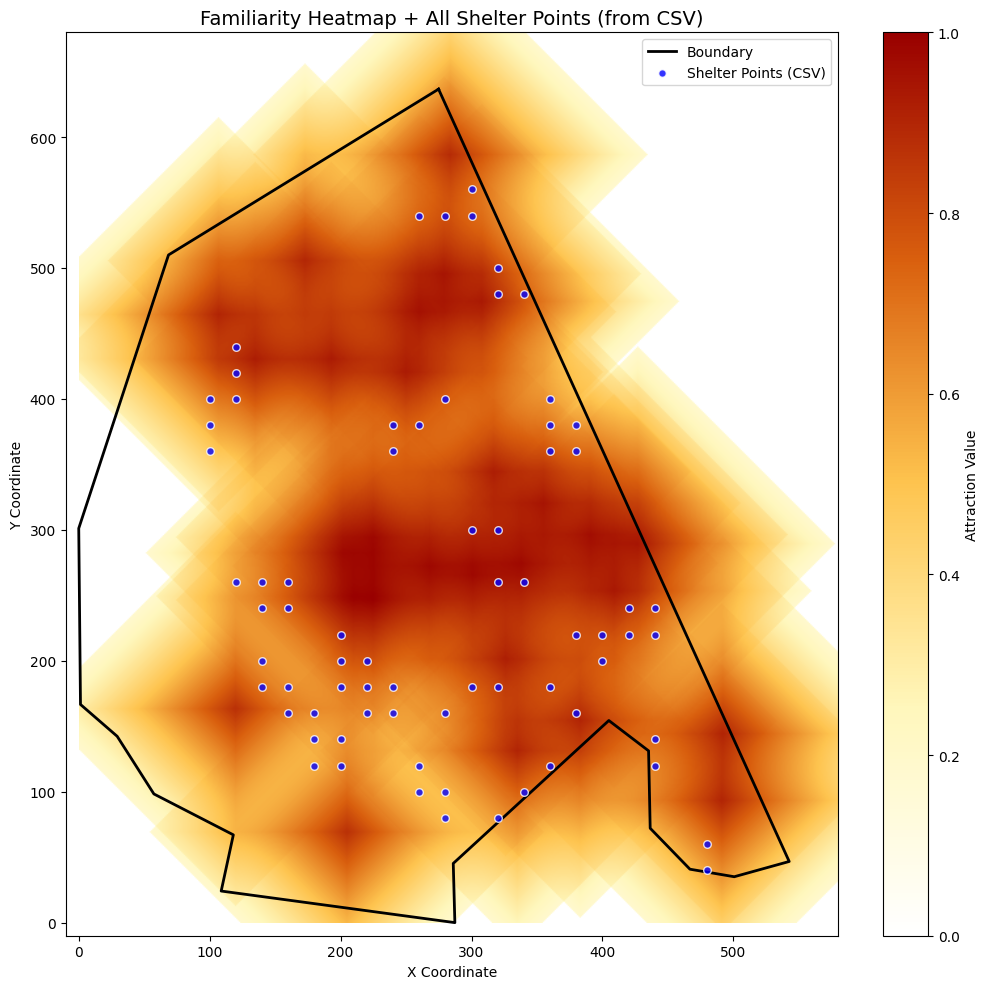

In [ ]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_shelter_csv(json_path, boundary_path, csv_path, grid_size=(700, 700)):
    # 1. 加载熟悉度热力图数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)

    # 2. 加载 CSV 坐标点
    shelter_df = pd.read_csv(csv_path)

    # 3. 创建自定义色带
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    # 4. 绘图
    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 绘制热力图底图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=1.0,
        zorder=1
    )

    # 5. 叠加边界线
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=2, label='Boundary', zorder=3)

    # 6. 【核心步骤】叠加 CSV 中的 71 个避难所坐标点
    plt.scatter(
        shelter_df['x'], 
        shelter_df['y'], 
        c='blue', 
        s=30, 
        marker='o', 
        edgecolors='white', 
        label='Shelter Points (CSV)', 
        zorder=4,
        alpha=0.8
    )

    # 7. 设置坐标范围与细节
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title("Familiarity Heatmap + All Shelter Points (from CSV)", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Attraction Value')

    plt.legend(loc='upper right')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points_normalized.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_shelter_csv(target_json, boundary_file, csv_file)

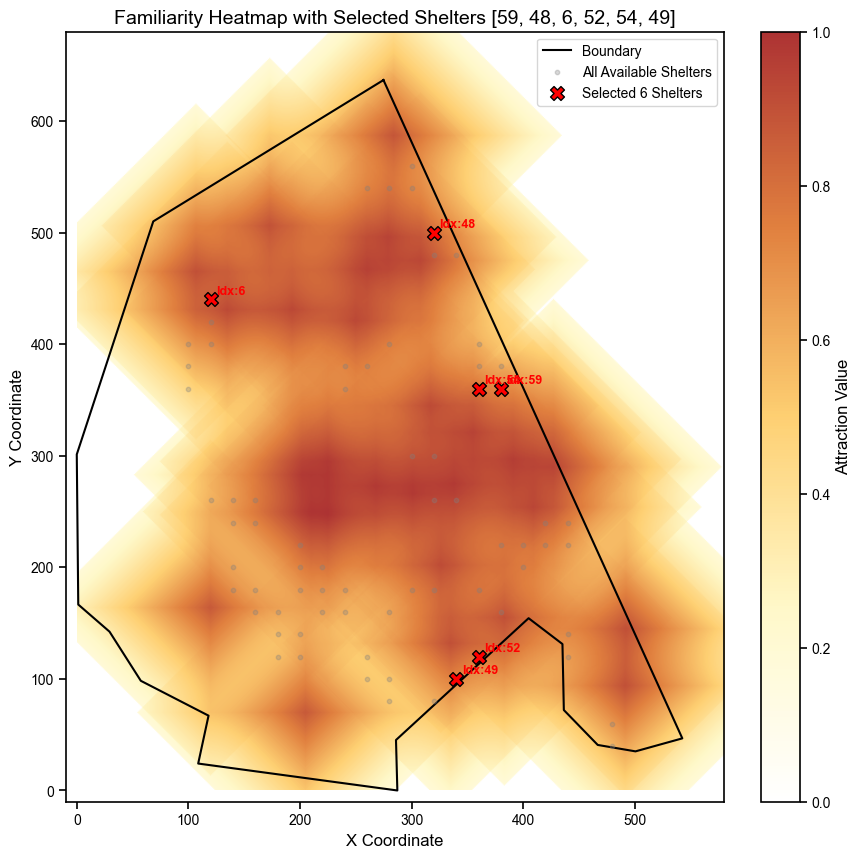

In [ ]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_selected_six(json_path, boundary_path, csv_path, selected_indices, grid_size=(700, 700)):
    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)
    
    shelter_df = pd.read_csv(csv_path)
    
    # 2. 筛选选中的 6 个点
    # 确保只选 6 个，并且索引在范围内
    selected_points = shelter_df[shelter_df['index'].isin(selected_indices)]

    # 3. 绘图配置
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 4. 绘制背景热力图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=0.8,
        zorder=1
    )

    # 5. 绘制边界
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='Boundary', zorder=2)

    # 6. 绘制所有背景点（浅灰色，较小）
    plt.scatter(shelter_df['x'], shelter_df['y'], c='gray', s=10, alpha=0.3, label='All Available Shelters', zorder=3)

    # 7. 【重点】绘制选中的 6 个高亮解
    plt.scatter(
        selected_points['x'], 
        selected_points['y'], 
        c='red', 
        s=100, 
        marker='X', 
        edgecolors='black', 
        label='Selected 6 Shelters', 
        zorder=5
    )

    # 给这 6 个点加上索引标注
    for i, row in selected_points.iterrows():
        plt.text(row['x'] + 5, row['y'] + 5, f"Idx:{int(row['index'])}", 
                 fontsize=9, fontweight='bold', color='red', zorder=6)

    # 8. 细节打磨
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title(f"Familiarity Heatmap with Selected Shelters {selected_indices}", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.colorbar(img, fraction=0.046, pad=0.04, label='Attraction Value')
    plt.legend(loc='upper right')
    plt.grid(False)
    plt.show()

# --- 你只需要修改这里的 6 个索引 ---
# 示例：根据你之前 GA 日志里的 Top1 个体索引 [19, 22, 33, 52, 59, 64]
#my_six_indices = [6, 47, 52, 20, 62, 67]
#my_six_indices = [64, 29, 50, 45, 51, 52]
#my_six_indices = [5, 36, 38, 53, 64, 67]
my_six_indices = [6, 29, 45, 48, 66, 70] #baseline

my_six_indices = [62, 13, 64, 59, 47, 44] #S1 high
#my_six_indices = [50, 56, 38, 44, 28, 46] #S1    
#my_six_indices = [59, 33, 54, 14, 13, 29] #S2 
my_six_indices = [59, 48, 6, 52, 54, 49] #S3
#my_six_indices = [0, 22, 29, 33, 28, 54] #S4


base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points_normalized.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_selected_six(target_json, boundary_file, csv_file, my_six_indices)


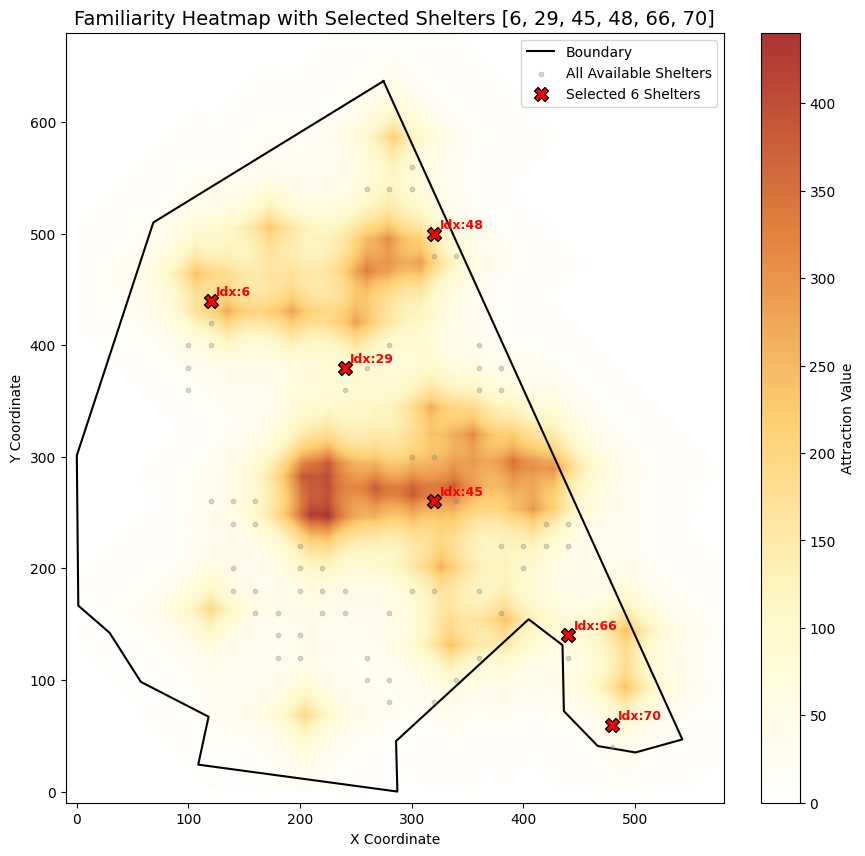

In [ ]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_selected_six(json_path, boundary_path, csv_path, selected_indices, grid_size=(700, 700)):
    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)
    
    shelter_df = pd.read_csv(csv_path)
    
    # 2. 筛选选中的 6 个点
    # 确保只选 6 个，并且索引在范围内
    selected_points = shelter_df[shelter_df['index'].isin(selected_indices)]

    # 3. 绘图配置
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 4. 绘制背景热力图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=0.8,
        zorder=1
    )

    # 5. 绘制边界
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='Boundary', zorder=2)

    # 6. 绘制所有背景点（浅灰色，较小）
    plt.scatter(shelter_df['x'], shelter_df['y'], c='gray', s=10, alpha=0.3, label='All Available Shelters', zorder=3)

    # 7. 【重点】绘制选中的 6 个高亮解
    plt.scatter(
        selected_points['x'], 
        selected_points['y'], 
        c='red', 
        s=100, 
        marker='X', 
        edgecolors='black', 
        label='Selected 6 Shelters', 
        zorder=5
    )

    # 给这 6 个点加上索引标注
    for i, row in selected_points.iterrows():
        plt.text(row['x'] + 5, row['y'] + 5, f"Idx:{int(row['index'])}", 
                 fontsize=9, fontweight='bold', color='red', zorder=6)

    # 8. 细节打磨
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title(f"Familiarity Heatmap with Selected Shelters {selected_indices}", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.colorbar(img, fraction=0.046, pad=0.04, label='Attraction Value')
    plt.legend(loc='upper right')
    plt.grid(False)
    plt.show()

# --- 你只需要修改这里的 6 个索引 ---
# 示例：根据你之前 GA 日志里的 Top1 个体索引 [19, 22, 33, 52, 59, 64]
my_six_indices = [6, 29, 45, 48, 66, 70]

base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_selected_six(target_json, boundary_file, csv_file, my_six_indices)



In [1]:
# ===== 在 OSM 底图上绘制避难所位置（顶刊标准） =====

import geopandas as gpd
import contextily as ctx
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from shapely.geometry import Polygon
import os
import json
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


In [2]:

# 设置学术发表风格
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

# 坐标转换函数
def convert_local_to_epsg3415(local_coords, offset=(519992.29, 686986.98)):
    """将本地坐标转换回 EPSG:3415"""
    x_local, y_local = local_coords
    x_epsg = x_local + offset[0]
    y_epsg = y_local + offset[1]
    return (x_epsg, y_epsg)

def convert_epsg3415_to_wgs84(epsg3415_coords):
    """将 EPSG:3415 转换为 WGS84 (EPSG:4326)"""
    transformer = Transformer.from_crs("EPSG:3415", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(epsg3415_coords[0], epsg3415_coords[1])
    return (lon, lat)

def convert_local_to_wgs84(local_coords, offset=(519992.29, 686986.98)):
    """将本地坐标转换为 WGS84"""
    epsg3415_coord = convert_local_to_epsg3415(local_coords, offset)
    return convert_epsg3415_to_wgs84(epsg3415_coord)

def plot_shelters_on_osm_map(boundary_geojson_path,
                              shelter_csv_path,
                              offset=(519992.29, 686986.98),
                              output_path=None, 
                              dpi=300, 
                              save_format='pdf',
                              show_all_shelters=True,
                              selected_indices=None):
    """
    在 OSM 底图上绘制避难所位置（顶刊标准）
    
    参数:
    - boundary_geojson_path: 真实边界 GeoJSON 路径（EPSG:4326）
    - shelter_csv_path: 避难所 CSV 文件路径（包含 index, x, y 列，本地坐标）
    - offset: 坐标偏移量（用于转换本地坐标到 WGS84）
    - output_path: 保存路径
    - dpi: 分辨率
    - save_format: 保存格式
    - show_all_shelters: 是否显示所有避难所
    - selected_indices: 如果指定，只显示这些索引的避难所（用于高亮选中的避难所）
    """
    # 1. 加载真实边界（EPSG:4326）
    boundary_gdf = gpd.read_file(boundary_geojson_path)
    if boundary_gdf.crs is None:
        boundary_gdf.set_crs(epsg=4326, inplace=True)
    
    # 2. 读取避难所数据
    shelter_df = pd.read_csv(shelter_csv_path)
    print(f"✓ 读取到 {len(shelter_df)} 个避难所点")
    
    # 3. 筛选要显示的避难所
    if selected_indices is not None:
        display_df = shelter_df[shelter_df['index'].isin(selected_indices)].copy()
        print(f"✓ 显示选中的 {len(display_df)} 个避难所")
    else:
        display_df = shelter_df.copy()
    
    # 4. 转换避难所坐标到 WGS84
    shelters_wgs84 = []
    for _, row in display_df.iterrows():
        wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
        shelters_wgs84.append({
            'index': row['index'],
            'lon': wgs84_coord[0],
            'lat': wgs84_coord[1]
        })
    
    shelters_gdf = gpd.GeoDataFrame(
        shelters_wgs84,
        geometry=gpd.points_from_xy(
            [s['lon'] for s in shelters_wgs84],
            [s['lat'] for s in shelters_wgs84]
        ),
        crs="EPSG:4326"
    )
    
    # 5. 转换为 Web Mercator (EPSG:3857) 以便使用 OSM 底图
    boundary_web = boundary_gdf.to_crs(epsg=3857)
    shelters_web = shelters_gdf.to_crs(epsg=3857)
    
    # 6. 创建图形
    fig, ax = plt.subplots(figsize=(10, 10), dpi=dpi, facecolor='white')
    
    # 7. 先绘制边界（不显示）以设置坐标轴范围
    boundary_web.plot(ax=ax, alpha=0.0)
    ax.set_aspect('equal')
    
    # 获取边界框用于设置范围
    bounds = boundary_web.total_bounds
    margin = (bounds[2] - bounds[0]) * 0.1  # 10% 边距
    ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
    ax.set_ylim(bounds[1] - margin, bounds[3] + margin)
    
    # 8. 添加 OSM 底图
    try:
        ctx.add_basemap(
            ax,
            crs=boundary_web.crs,
            source=ctx.providers.CartoDB.Positron,  # 简洁风格，适合发表
            zoom='auto',
            alpha=0.8
        )
        print("✓ OSM 底图加载成功")
    except Exception as e:
        print(f"警告：无法加载 OSM 底图: {e}")
        import traceback
        traceback.print_exc()
    
    # 9. 绘制边界填充
    boundary_web.plot(ax=ax, color='#f5f5f5', alpha=0.3, edgecolor='none', zorder=1)
    
    # 10. 绘制所有避难所（如果显示全部）
    if show_all_shelters and selected_indices is None:
        # 绘制所有避难所（较小，灰色）
        all_shelters_wgs84 = []
        for _, row in shelter_df.iterrows():
            wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
            all_shelters_wgs84.append({
                'lon': wgs84_coord[0],
                'lat': wgs84_coord[1]
            })
        
        all_shelters_gdf = gpd.GeoDataFrame(
            all_shelters_wgs84,
            geometry=gpd.points_from_xy(
                [s['lon'] for s in all_shelters_wgs84],
                [s['lat'] for s in all_shelters_wgs84]
            ),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)
        
        all_shelters_gdf.plot(
            ax=ax,
            color='gray',
            markersize=15,
            alpha=0.4,
            edgecolors='white',
            linewidths=0.3,
            zorder=2,
            label='All Candidate Shelters'
        )
    
    # 11. 绘制选中的避难所（或所有避难所，如果未指定选中）
    # 使用醒目的高端配色和空心长方体（正方形）标记，适合顶刊风格
    highlight_color = "#FFB300"    # 鲜艳橙色 (顶刊常用色)
    edge_color = "#44475a"         # 深灰蓝，风格高级
    marker_shape = "s"             # "s" 表示正方形
    
    if selected_indices is not None:
        # 高亮选中的避难所（更大，空心正方形/长方体，有深色边框，填充透明/白色）
        shelters_web.plot(
            ax=ax,
            marker=marker_shape,
            facecolor="none",           # 空心
            edgecolor=highlight_color,  # 鲜艳边框
            linewidth=3.0,              # 更粗的边框
            markersize=180,             # 更大
            zorder=4,
            label="Selected Shelters"
        )
    else:
        # 显示所有避难所（正常较大，空心正方形，柔和色）
        shelters_web.plot(
            ax=ax,
            marker=marker_shape,
            facecolor="none",
            edgecolor=edge_color,
            linewidth=2.0,
            markersize=100,
            zorder=3,
            label="Shelter Locations"
        )
    
    # 12. 绘制边界线
    boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2.0, zorder=5, label='Campus Boundary')
    
    # 13. 设置坐标轴
    ax.set_xlabel('Longitude', fontsize=12, fontweight='normal')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='normal')
    ax.tick_params(axis='both', which='major', length=5, width=1.2, labelsize=10)
    
    # 14. 图例
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2.0, label='Campus Boundary'),
    ]
    
    if show_all_shelters and selected_indices is None:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#4A90E2',
                   markeredgecolor='white', markersize=8, markeredgewidth=1.5,
                   label='Shelter Locations')
        )
    elif selected_indices is not None:
        if show_all_shelters:
            legend_elements.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                       markeredgecolor='white', markersize=6, markeredgewidth=0.3,
                       label='All Candidate Shelters')
            )
        legend_elements.append(
            Line2D([0], [0], marker='X', color='w', markerfacecolor='red',
                   markeredgecolor='darkred', markersize=12, markeredgewidth=2.0,
                   label='Selected Shelters')
        )
    
    ax.legend(handles=legend_elements, loc='upper right',
             frameon=True, fancybox=False, shadow=False,
             framealpha=0.95, edgecolor='gray', facecolor='white', fontsize=10)
    
    # 15. 移除不必要的元素
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    
    # 16. 调整布局
    plt.tight_layout()
    
    # 17. 保存或显示
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.1)
        print(f"✓ 已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    
    plt.close()

# ===== 执行代码 =====
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data", "boundary.geojson")
shelter_csv = os.path.join(base_path, "data", "output", "shelter_points.csv")

print("=" * 60)
print("在 OSM 底图上绘制所有避难所位置")
print("=" * 60)

# 绘制所有避难所
plot_shelters_on_osm_map(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "shelters_osm_all_publication.pdf"),
    dpi=300,
    save_format='pdf',
    show_all_shelters=True,
    selected_indices=None
)

plot_shelters_on_osm_map(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "shelters_osm_all_publication.png"),
    dpi=600,
    save_format='png',
    show_all_shelters=True,
    selected_indices=None
)

# 如果需要高亮选中的避难所，取消下面的注释并指定索引
# selected_shelters = [5, 36, 38, 53, 64, 67]  # 示例：选中的避难所索引
# plot_shelters_on_osm_map(
#     boundary_geojson_path=boundary_file,
#     shelter_csv_path=shelter_csv,
#     offset=(519992.29, 686986.98),
#     output_path=os.path.join(base_path, "data_empirical", "shelters_osm_selected_publication.pdf"),
#     dpi=300,
#     save_format='pdf',
#     show_all_shelters=True,
#     selected_indices=selected_shelters
# )

print("\n✓ 所有地图生成完成！")

在 OSM 底图上绘制所有避难所位置
✓ 读取到 71 个避难所点
✓ OSM 底图加载成功
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\shelters_osm_all_publication.pdf (DPI=300, 格式=pdf)
✓ 读取到 71 个避难所点
✓ OSM 底图加载成功
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\shelters_osm_all_publication.png (DPI=600, 格式=png)

✓ 所有地图生成完成！


### optimal shelters visualization 

In [3]:
# ===== 在 OSM 底图上绘制避难所位置（顶刊标准）- 使用真实经纬度 =====

import geopandas as gpd
import contextily as ctx
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from shapely.geometry import Polygon
import os
import json
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# 设置学术发表风格
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

# 坐标转换函数
def convert_local_to_epsg3415(local_coords, offset=(519992.29, 686986.98)):
    x_local, y_local = local_coords
    x_epsg = x_local + offset[0]
    y_epsg = y_local + offset[1]
    return (x_epsg, y_epsg)

def convert_epsg3415_to_wgs84(epsg3415_coords):
    transformer = Transformer.from_crs("EPSG:3415", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(epsg3415_coords[0], epsg3415_coords[1])
    return (lon, lat)

def convert_local_to_wgs84(local_coords, offset=(519992.29, 686986.98)):
    epsg3415_coord = convert_local_to_epsg3415(local_coords, offset)
    return convert_epsg3415_to_wgs84(epsg3415_coord)

def plot_shelters_on_osm_map(boundary_geojson_path,
                             shelter_csv_path,
                             offset=(519992.29, 686986.98),
                             output_path=None, 
                             dpi=300, 
                             save_format='pdf',
                             show_all_shelters=True,
                             selected_indices=None,
                             basemap_source='cartodb_positron'):
    """
    在 OSM 底图上绘制避难所位置（顶刊标准）- 使用真实经纬度坐标轴

    参数:
    - boundary_geojson_path: 边界 GeoJSON 路径（EPSG:4326）
    - shelter_csv_path: 避难所 CSV 文件路径（包含 index, x, y 列，使用本地坐标）
    - offset: 坐标偏移量（用于转换本地坐标到 WGS84）
    - output_path: 保存路径
    - dpi: 分辨率
    - save_format: 保存格式
    - show_all_shelters: 是否显示所有候选避难所
    - selected_indices: 如果指定，只显示这些索引的避难所（并高亮）
    - basemap_source: 底图来源
        - 'cartodb_positron': CartoDB Positron（简洁，推荐发表用）
        - 'osm': OpenStreetMap Mapnik（标准 OSM）
        - 'cartodb_voyager': CartoDB Voyager（彩色风格）
        - 'cartodb_dark': CartoDB DarkMatter（深色风格）
        - 'esri_worldimagery': ESRI World Imagery（卫星图）
        - 'esri_worldstreetmap': ESRI World Street Map（ESRI 街道图）
    """
    # 1. 加载边界（EPSG:4326）
    boundary_gdf = gpd.read_file(boundary_geojson_path)
    if boundary_gdf.crs is None:
        boundary_gdf.set_crs(epsg=4326, inplace=True)
    bounds_wgs84 = boundary_gdf.total_bounds  # [min_lon, min_lat, max_lon, max_lat]
    
    # 2. 读取避难所
    shelter_df = pd.read_csv(shelter_csv_path)
    print(f"✓ 读取到 {len(shelter_df)} 个避难所点")
    
    # 3. 筛选显示的避难所
    if selected_indices is not None:
        display_df = shelter_df[shelter_df['index'].isin(selected_indices)].copy()
        print(f"✓ 显示选中的 {len(display_df)} 个避难所")
    else:
        display_df = shelter_df.copy()
    
    # 4. 本地坐标转 WGS84
    shelters_wgs84 = []
    for _, row in display_df.iterrows():
        wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
        shelters_wgs84.append({
            'index': row['index'],
            'lon': wgs84_coord[0],
            'lat': wgs84_coord[1]
        })
    shelters_gdf = gpd.GeoDataFrame(
        shelters_wgs84,
        geometry=gpd.points_from_xy(
            [s['lon'] for s in shelters_wgs84],
            [s['lat'] for s in shelters_wgs84]
        ),
        crs="EPSG:4326"
    )
    
    # 5. 转换为 Web Mercator
    boundary_web = boundary_gdf.to_crs(epsg=3857)
    shelters_web = shelters_gdf.to_crs(epsg=3857)

    # 6. 创建图形
    fig, ax = plt.subplots(figsize=(10, 10), dpi=dpi, facecolor='white')
    boundary_web.plot(ax=ax, alpha=0.0)
    ax.set_aspect('equal')

    bounds_web = boundary_web.total_bounds
    margin = (bounds_web[2] - bounds_web[0]) * 0.1
    ax.set_xlim(bounds_web[0] - margin, bounds_web[2] + margin)
    ax.set_ylim(bounds_web[1] - margin, bounds_web[3] + margin)

    # 7. 底图来源
    basemap_sources = {
        'cartodb_positron': ctx.providers.CartoDB.Positron,
        'osm': ctx.providers.OpenStreetMap.Mapnik,
        'cartodb_voyager': ctx.providers.CartoDB.Voyager,
        'cartodb_dark': ctx.providers.CartoDB.DarkMatter,
    }
    try:
        basemap_sources['esri_worldimagery'] = ctx.providers.Esri.WorldImagery
        basemap_sources['esri_worldstreetmap'] = ctx.providers.Esri.WorldStreetMap
    except AttributeError:
        pass
    basemap = basemap_sources.get(basemap_source, ctx.providers.CartoDB.Positron)

    try:
        ctx.add_basemap(
            ax, crs=boundary_web.crs,
            source=basemap,
            zoom='auto',
            alpha=0.8
        )
        print(f"✓ OSM 底图加载成功（来源: {basemap_source}）")
    except Exception as e:
        print(f"警告：无法加载底图 '{basemap_source}': {e}")
        print(f"尝试使用默认底图 'cartodb_positron'...")
        try:
            ctx.add_basemap(
                ax, crs=boundary_web.crs,
                source=ctx.providers.CartoDB.Positron,
                zoom='auto',
                alpha=0.8
            )
            print("✓ 默认底图加载成功")
        except Exception as e2:
            print(f"错误：无法加载默认底图: {e2}")
            import traceback
            traceback.print_exc()

    # 8. 边界填充
    boundary_web.plot(ax=ax, color='#f5f5f5', alpha=0.3, edgecolor='none', zorder=1)

    # 9. 全部候选避难所（背景, 灰色圆点, 统一图注名 All shelters）
    if show_all_shelters and selected_indices is None:
        all_shelters_wgs84 = []
        for _, row in shelter_df.iterrows():
            wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
            all_shelters_wgs84.append({
                'lon': wgs84_coord[0],
                'lat': wgs84_coord[1]
            })
        all_shelters_gdf = gpd.GeoDataFrame(
            all_shelters_wgs84,
            geometry=gpd.points_from_xy(
                [s['lon'] for s in all_shelters_wgs84],
                [s['lat'] for s in all_shelters_wgs84]
            ),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)
        all_shelters_gdf.plot(
            ax=ax,
            color='gray',
            markersize=15,
            alpha=0.4,
            edgecolors='white',
            linewidths=0.3,
            zorder=2,
            label='All shelters'
        )

    # 10. 显示重点/全部避难所（方形空心, 主色, 统一图注名 Shelters）
    highlight_color = "#FFB300"    # 醒目橙
    edge_color = "#44475a"         # 深灰蓝
    marker_shape = "s"             # 方块
    # 如果有 selected_indices，画高亮，否则画全体
    if selected_indices is not None:
        shelters_web.plot(
            ax=ax,
            marker=marker_shape,
            facecolor="none",           # 空心
            edgecolor=highlight_color,
            linewidth=3.0,
            markersize=180,
            zorder=4,
            label="Highlighted shelters"
        )
        # 若要一并绘制所有点，可自行加上相关代码做阴影
        if show_all_shelters:
            # 灰圆表示所有点背景（该分支情况下 seldom 用, 但支持)
            all_shelters_wgs84 = []
            for _, row in shelter_df.iterrows():
                wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
                all_shelters_wgs84.append({
                    'lon': wgs84_coord[0],
                    'lat': wgs84_coord[1]
                })
            all_shelters_gdf = gpd.GeoDataFrame(
                all_shelters_wgs84,
                geometry=gpd.points_from_xy(
                    [s['lon'] for s in all_shelters_wgs84],
                    [s['lat'] for s in all_shelters_wgs84]
                ),
                crs="EPSG:4326"
            ).to_crs(epsg=3857)
            all_shelters_gdf.plot(
                ax=ax,
                color='gray',
                markersize=15,
                alpha=0.4,
                edgecolors='white',
                linewidths=0.3,
                zorder=2,
                label='All shelters'
            )
    else:
        shelters_web.plot(
            ax=ax,
            marker=marker_shape,
            facecolor="none",
            edgecolor=edge_color,
            linewidth=2.0,
            markersize=100,
            zorder=3,
            label="Shelters"
        )

    # 11. 边界线
    boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2.0, zorder=5, label='Boundary')

    # 12. 坐标轴
    transformer_3857_to_4326 = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    bottom_left = transformer_3857_to_4326.transform(xlim[0], ylim[0])
    top_right = transformer_3857_to_4326.transform(xlim[1], ylim[1])

    ax.set_xlabel('Longitude (°)', fontsize=12, fontweight='normal')
    ax.set_ylabel('Latitude (°)', fontsize=12, fontweight='normal')

    lon_ticks = np.linspace(bounds_wgs84[0], bounds_wgs84[2], 5)
    lat_ticks = np.linspace(bounds_wgs84[1], bounds_wgs84[3], 5)
    lon_ticks_web = []
    lat_ticks_web = []
    transformer_4326_to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    for lon in lon_ticks:
        lon_web, _ = transformer_4326_to_3857.transform(lon, bounds_wgs84[1])
        lon_ticks_web.append(lon_web)
    for lat in lat_ticks:
        _, lat_web = transformer_4326_to_3857.transform(bounds_wgs84[0], lat)
        lat_ticks_web.append(lat_web)
    ax.set_xticks(lon_ticks_web)
    ax.set_xticklabels([f'{lon:.4f}' for lon in lon_ticks], fontsize=10)
    ax.set_yticks(lat_ticks_web)
    ax.set_yticklabels([f'{lat:.4f}' for lat in lat_ticks], fontsize=10)
    ax.tick_params(axis='both', which='major', length=5, width=1.2)

    # 13. 统一图例
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2.0, label='Outline')
    ]
    # 情况1：只显示 Shelters（标准不高亮, 没有所有圆点）
    if selected_indices is None:
        legend_elements.append(
            Line2D([0], [0], marker=marker_shape, color='w', markerfacecolor='none',
                   markeredgecolor=edge_color, markersize=11, markeredgewidth=2,
                   linewidth=0, label='All candidate shelter sites')
        )
    # 情况2：只显示所有候选（灰色圆点）
    if show_all_shelters and selected_indices is None:
        legend_elements.insert(1,
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                   markeredgecolor='white', markersize=7, markeredgewidth=1.2,
                   linewidth=0, label='Available shelter center')
        )
    # 情况3：高亮主选 shelters（橙方）
    if selected_indices is not None:
        legend_elements.append(
            Line2D([0], [0], marker=marker_shape, color='w', markerfacecolor='none',
                   markeredgecolor=highlight_color, markersize=13, markeredgewidth=3,
                   linewidth=0, label='Optimal shelters')
        )
        if show_all_shelters:
            legend_elements.insert(1,
                Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                       markeredgecolor='white', markersize=7, markeredgewidth=1.2,
                       linewidth=0, label='All candidate shelter sites')
            )

    ax.legend(
        handles=legend_elements, loc='upper right',
        frameon=True, fancybox=False, shadow=False,
        framealpha=0.95, edgecolor='gray', facecolor='white', fontsize=10
    )

    # 14. 美化
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    plt.tight_layout()

    # 15. 输出/显示
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.1)
        print(f"✓ 已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    plt.close()

# ===== 执行代码 =====
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data", "boundary.geojson")
shelter_csv = os.path.join(base_path, "data", "output", "shelter_points.csv")

print("=" * 60)
print("在 OSM 底图上绘制所有避难所位置（使用真实经纬度）")
print("=" * 60)

# 可选底图来源（推荐 CartoDB Positron 发表用，其它风格请自行切换）:
# - 'cartodb_positron': CartoDB Positron
# - 'osm': OpenStreetMap Mapnik
# - 'cartodb_voyager': CartoDB Voyager
# - 'cartodb_dark': CartoDB DarkMatter
# - 'esri_worldimagery': ESRI World Imagery
# - 'esri_worldstreetmap': ESRI World Street Map

# 示例1：CartoDB Positron（推荐发表用）
plot_shelters_on_osm_map(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "shelters_osm_positron_publication.svg"),
    dpi=300,
    save_format='svg',
    show_all_shelters=True,
    selected_indices=None,
    basemap_source='cartodb_positron'
)

# 示例2：OpenStreetMap Mapnik（标准 OSM）
plot_shelters_on_osm_map(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "shelters_osm_mapnik_publication.svg"),
    dpi=300,
    save_format='svg',
    show_all_shelters=True,
    selected_indices=None,
    basemap_source='osm'
)

# 示例3：CartoDB Voyager（彩色）
plot_shelters_on_osm_map(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "shelters_osm_voyager_publication.svg"),
    dpi=300,
    save_format='svg',
    show_all_shelters=True,
    selected_indices=None,
    basemap_source='cartodb_voyager'
)

# 示例3：CartoDB Voyager（彩色）
plot_shelters_on_osm_map(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "optimal_shelters_osm_voyager_publication.svg"),
    dpi=300,
    save_format='svg',
    show_all_shelters=True,
    selected_indices=[6, 29, 45, 48, 66, 70],
    basemap_source='cartodb_voyager'
)
print("\n✓ 所有地图生成完成！")

在 OSM 底图上绘制所有避难所位置（使用真实经纬度）
✓ 读取到 71 个避难所点
✓ OSM 底图加载成功（来源: cartodb_positron）
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\shelters_osm_positron_publication.svg (DPI=300, 格式=svg)
✓ 读取到 71 个避难所点
✓ OSM 底图加载成功（来源: osm）
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\shelters_osm_mapnik_publication.svg (DPI=300, 格式=svg)
✓ 读取到 71 个避难所点
✓ OSM 底图加载成功（来源: cartodb_voyager）
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\shelters_osm_voyager_publication.svg (DPI=300, 格式=svg)
✓ 读取到 71 个避难所点
✓ 显示选中的 6 个避难所
✓ OSM 底图加载成功（来源: cartodb_voyager）
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\optimal_shelters_osm_voyager_publication.svg (DPI=300, 格式=svg)

✓ 所有地图生成完成！


In [103]:
# ===== 绘制多组 Optimal Shelters（四组选择）=====

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from matplotlib.lines import Line2D
import os

# 设置学术发表风格
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
})

# 坐标转换函数（复用原有函数）
def convert_local_to_epsg3415(local_coords, offset=(519992.29, 686986.98)):
    x_local, y_local = local_coords
    x_epsg = x_local + offset[0]
    y_epsg = y_local + offset[1]
    return (x_epsg, y_epsg)

def convert_epsg3415_to_wgs84(epsg3415_coords):
    transformer = Transformer.from_crs("EPSG:3415", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(epsg3415_coords[0], epsg3415_coords[1])
    return (lon, lat)

def convert_local_to_wgs84(local_coords, offset=(519992.29, 686986.98)):
    epsg3415_coord = convert_local_to_epsg3415(local_coords, offset)
    return convert_epsg3415_to_wgs84(epsg3415_coord)

def plot_multiple_optimal_shelters(
    boundary_geojson_path,
    shelter_csv_path,
    optimal_selections,  # 字典：{selection_name: [indices], ...}
    offset=(519992.29, 686986.98),
    output_path=None, 
    dpi=300, 
    save_format='pdf',
    show_all_shelters=True,
    basemap_source='cartodb_positron',
    color_palette=None  # 可选：自定义颜色列表
):
    """
    在 OSM 底图上绘制多组 optimal shelters（每组不同颜色）
    
    参数:
    - boundary_geojson_path: 边界 GeoJSON 路径（EPSG:4326）
    - shelter_csv_path: 避难所 CSV 文件路径
    - optimal_selections: 字典，格式为 {selection_name: [indices], ...}
        例如: {
            "S_{B0}^*": [6, 29, 45],
            "S_{S1}^*": [48, 66, 70],
            "S_{S2}^*": [12, 35, 58],
            "S_{S3}^*": [20, 42, 75]
        }
    - offset: 坐标偏移量
    - output_path: 保存路径
    - dpi: 分辨率
    - save_format: 保存格式
    - show_all_shelters: 是否显示所有候选避难所（灰色背景）
    - basemap_source: 底图来源
    - color_palette: 自定义颜色列表（如果为None，使用默认颜色）
    """
    
    # 默认颜色方案（四组不同颜色）
    if color_palette is None:
        default_colors = [
            "#FF6B6B",  # 红色
            "#4ECDC4",  # 青色
            "#45B7D1",  # 蓝色
            "#FFA07A",  # 橙色
        ]
        # 如果超过4组，使用matplotlib的tab10调色板
        if len(optimal_selections) > 4:
            import matplotlib.cm as cm
            default_colors = [cm.tab10(i) for i in range(len(optimal_selections))]
        color_palette = default_colors[:len(optimal_selections)]
    
    # 1. 加载边界
    boundary_gdf = gpd.read_file(boundary_geojson_path)
    if boundary_gdf.crs is None:
        boundary_gdf.set_crs(epsg=4326, inplace=True)
    bounds_wgs84 = boundary_gdf.total_bounds
    
    # 2. 读取避难所
    shelter_df = pd.read_csv(shelter_csv_path)
    print(f"✓ 读取到 {len(shelter_df)} 个避难所点")
    
    # 3. 转换为 Web Mercator
    boundary_web = boundary_gdf.to_crs(epsg=3857)
    
    # 4. 创建图形
    fig, ax = plt.subplots(figsize=(10, 10), dpi=dpi, facecolor='white')
    boundary_web.plot(ax=ax, alpha=0.0)
    ax.set_aspect('equal')
    
    bounds_web = boundary_web.total_bounds
    margin = (bounds_web[2] - bounds_web[0]) * 0.1
    ax.set_xlim(bounds_web[0] - margin, bounds_web[2] + margin)
    ax.set_ylim(bounds_web[1] - margin, bounds_web[3] + margin)
    
    # 5. 加载底图
    basemap_sources = {
        'cartodb_positron': ctx.providers.CartoDB.Positron,
        'osm': ctx.providers.OpenStreetMap.Mapnik,
        'cartodb_voyager': ctx.providers.CartoDB.Voyager,
        'cartodb_dark': ctx.providers.CartoDB.DarkMatter,
    }
    try:
        basemap_sources['esri_worldimagery'] = ctx.providers.Esri.WorldImagery
        basemap_sources['esri_worldstreetmap'] = ctx.providers.Esri.WorldStreetMap
    except AttributeError:
        pass
    basemap = basemap_sources.get(basemap_source, ctx.providers.CartoDB.Positron)
    
    try:
        ctx.add_basemap(
            ax, crs=boundary_web.crs,
            source=basemap,
            zoom='auto',
            alpha=0.8
        )
        print(f"✓ OSM 底图加载成功（来源: {basemap_source}）")
    except Exception as e:
        print(f"警告：无法加载底图 '{basemap_source}': {e}")
        try:
            ctx.add_basemap(
                ax, crs=boundary_web.crs,
                source=ctx.providers.CartoDB.Positron,
                zoom='auto',
                alpha=0.8
            )
            print("✓ 默认底图加载成功")
        except Exception as e2:
            print(f"错误：无法加载默认底图: {e2}")
    
    # 6. 边界填充
    boundary_web.plot(ax=ax, color='#f5f5f5', alpha=0.3, edgecolor='none', zorder=1)
    
    # 7. 显示所有候选避难所（灰色背景，如果启用）
    if show_all_shelters:
        all_shelters_wgs84 = []
        for _, row in shelter_df.iterrows():
            wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
            all_shelters_wgs84.append({
                'lon': wgs84_coord[0],
                'lat': wgs84_coord[1]
            })
        all_shelters_gdf = gpd.GeoDataFrame(
            all_shelters_wgs84,
            geometry=gpd.points_from_xy(
                [s['lon'] for s in all_shelters_wgs84],
                [s['lat'] for s in all_shelters_wgs84]
            ),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)
        all_shelters_gdf.plot(
            ax=ax,
            color='gray',
            markersize=15,
            alpha=0.4,
            edgecolors='white',
            linewidths=0.3,
            zorder=2,
            label='All available shelters'
        )
    
    # 8. 绘制每组 optimal shelters（不同颜色）
    marker_shape = "s"  # 方形
    zorder_start = 3
    
    legend_elements = []
    
    for idx, (selection_name, indices) in enumerate(optimal_selections.items()):
        if not indices:  # 跳过空列表
            continue
            
        # 获取该组的颜色
        color = color_palette[idx % len(color_palette)]
        
        # 筛选该组的避难所
        group_df = shelter_df[shelter_df['index'].isin(indices)].copy()
        
        # 转换为 WGS84
        group_shelters_wgs84 = []
        for _, row in group_df.iterrows():
            wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
            group_shelters_wgs84.append({
                'lon': wgs84_coord[0],
                'lat': wgs84_coord[1]
            })
        
        group_shelters_gdf = gpd.GeoDataFrame(
            group_shelters_wgs84,
            geometry=gpd.points_from_xy(
                [s['lon'] for s in group_shelters_wgs84],
                [s['lat'] for s in group_shelters_wgs84]
            ),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)
        
        # 绘制该组（方形空心，使用该组颜色）
        group_shelters_gdf.plot(
            ax=ax,
            marker=marker_shape,
            facecolor="none",
            edgecolor=color,
            linewidth=3.0,
            markersize=180,
            zorder=zorder_start + idx,
            label=selection_name  # 使用 selection_name 作为图例标签
        )
        
        print(f"✓ 绘制 {selection_name}: {len(indices)} 个避难所（颜色: {color}）")
    
    # 9. 边界线
    boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2.0, zorder=5, label='Boundary')
    
    # 10. 坐标轴（真实经纬度）
    transformer_4326_to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    lon_ticks = np.linspace(bounds_wgs84[0], bounds_wgs84[2], 5)
    lat_ticks = np.linspace(bounds_wgs84[1], bounds_wgs84[3], 5)
    lon_ticks_web = [transformer_4326_to_3857.transform(lon, bounds_wgs84[1])[0] for lon in lon_ticks]
    lat_ticks_web = [transformer_4326_to_3857.transform(bounds_wgs84[0], lat)[1] for lat in lat_ticks]
    
    ax.set_xticks(lon_ticks_web)
    ax.set_xticklabels([f'{lon:.4f}' for lon in lon_ticks], fontsize=10, fontweight='bold')
    ax.set_yticks(lat_ticks_web)
    ax.set_yticklabels([f'{lat:.4f}' for lat in lat_ticks], fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitude (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', which='major', length=8, width=2.0, color='black', pad=8)
    
    # 11. 构建图例
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2.0, label='Boundary')
    ]
    
    # 添加所有候选避难所图例（如果显示）
    if show_all_shelters:
        legend_elements.insert(0,
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                   markeredgecolor='white', markersize=7, markeredgewidth=1.2,
                   linewidth=0, label='All available shelters')
        )
    
    # 添加每组 optimal shelters 的图例
    for idx, (selection_name, indices) in enumerate(optimal_selections.items()):
        if not indices:
            continue
        color = color_palette[idx % len(color_palette)]
        legend_elements.append(
            Line2D([0], [0], marker=marker_shape, color='w', markerfacecolor='none',
                   markeredgecolor=color, markersize=13, markeredgewidth=3,
                   linewidth=0, label=selection_name)
        )
    
    ax.legend(
        handles=legend_elements, loc='upper right',
        frameon=True, fancybox=False, shadow=False,
        framealpha=0.95, edgecolor='gray', facecolor='white', fontsize=10
    )
    
    # 12. 美化
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    plt.tight_layout()
    
    # 13. 保存
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.1)
        print(f"✓ 已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    plt.close()

# ===== 执行代码 =====
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data", "boundary.geojson")
shelter_csv = os.path.join(base_path, "data", "output", "shelter_points.csv")

print("=" * 60)
print("绘制多组 Optimal Shelters（四组选择）")
print("=" * 60)

# 定义四组 optimal selections
# 注意：这里需要根据你的实际数据填入正确的索引
optimal_selections = {
    r"$S_{B0}^*$": [6, 29, 45, 48, 66, 70],      
    r"$S_{S1}^*$": [50, 56, 38, 44, 28, 46],             
    r"$S_{S2}^*$": [0, 22, 29, 33, 28, 54],              
    r"$S_{S3}^*$": [59, 48, 6, 52, 54, 49],       
}



plot_multiple_optimal_shelters(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    optimal_selections=optimal_selections,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "multiple_optimal_shelters.pdf"),
    dpi=300,
    save_format='pdf',
    show_all_shelters=True,
    basemap_source='cartodb_voyager'  # 或 'cartodb_positron', 'osm' 等
)

print("\n✓ 多组 Optimal Shelters 地图生成完成！")

绘制多组 Optimal Shelters（四组选择）
✓ 读取到 71 个避难所点
✓ OSM 底图加载成功（来源: cartodb_voyager）
✓ 绘制 $S_{B0}^*$: 6 个避难所（颜色: #FF6B6B）
✓ 绘制 $S_{S1}^*$: 6 个避难所（颜色: #4ECDC4）
✓ 绘制 $S_{S2}^*$: 6 个避难所（颜色: #45B7D1）
✓ 绘制 $S_{S3}^*$: 6 个避难所（颜色: #FFA07A）
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\multiple_optimal_shelters.pdf (DPI=300, 格式=pdf)

✓ 多组 Optimal Shelters 地图生成完成！


In [2]:
# ===== 绘制多组 Optimal Shelters（四组选择，分四个子图）=====

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from matplotlib.lines import Line2D
import os

# 设置学术发表风格
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
    'axes.linewidth': 1.2,
})

# 坐标转换函数
def convert_local_to_epsg3415(local_coords, offset=(519992.29, 686986.98)):
    x_local, y_local = local_coords
    x_epsg = x_local + offset[0]
    y_epsg = y_local + offset[1]
    return (x_epsg, y_epsg)

def convert_epsg3415_to_wgs84(epsg3415_coords):
    transformer = Transformer.from_crs("EPSG:3415", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(epsg3415_coords[0], epsg3415_coords[1])
    return (lon, lat)

def convert_local_to_wgs84(local_coords, offset=(519992.29, 686986.98)):
    epsg3415_coord = convert_local_to_epsg3415(local_coords, offset)
    return convert_epsg3415_to_wgs84(epsg3415_coord)

def plot_multiple_optimal_shelters_subplots(
    boundary_geojson_path,
    shelter_csv_path,
    optimal_selections,  # 字典：{selection_name: [indices], ...}
    offset=(519992.29, 686986.98),
    output_path=None, 
    dpi=300, 
    save_format='pdf',
    show_all_shelters=True,
    basemap_source='cartodb_positron',
    color_palette=None  # 可选：自定义颜色列表
):
    """
    在 OSM 底图上绘制多组 optimal shelters（每组一个子图，组成2x2布局）
    
    参数:
    - boundary_geojson_path: 边界 GeoJSON 路径（EPSG:4326）
    - shelter_csv_path: 避难所 CSV 文件路径
    - optimal_selections: 字典，格式为 {selection_name: [indices], ...}
    - offset: 坐标偏移量
    - output_path: 保存路径
    - dpi: 分辨率
    - save_format: 保存格式
    - show_all_shelters: 是否显示所有候选避难所（灰色背景）
    - basemap_source: 底图来源
    - color_palette: 自定义颜色列表（如果为None，使用默认颜色）
    """
    
    # 默认颜色方案（四组不同颜色）
    if color_palette is None:
        default_colors = [
            "#FF6B6B",  # 红色
            "#4ECDC4",  # 青色
            "#45B7D1",  # 蓝色
            "#FFA07A",  # 橙色
        ]
        color_palette = default_colors[:len(optimal_selections)]
    
    # 1. 加载边界
    boundary_gdf = gpd.read_file(boundary_geojson_path)
    if boundary_gdf.crs is None:
        boundary_gdf.set_crs(epsg=4326, inplace=True)
    bounds_wgs84 = boundary_gdf.total_bounds
    
    # 2. 读取避难所
    shelter_df = pd.read_csv(shelter_csv_path)
    print(f"✓ 读取到 {len(shelter_df)} 个避难所点")
    
    # 3. 转换为 Web Mercator
    boundary_web = boundary_gdf.to_crs(epsg=3857)
    bounds_web = boundary_web.total_bounds
    margin = (bounds_web[2] - bounds_web[0]) * 0.1
    
    # 4. 创建2x2子图布局
    fig, axes = plt.subplots(2, 2, figsize=(16, 16), dpi=dpi, facecolor='white')
    axes = axes.flatten()  # 将2x2数组展平为1D数组
    
    # 5. 准备底图
    basemap_sources = {
        'cartodb_positron': ctx.providers.CartoDB.Positron,
        'osm': ctx.providers.OpenStreetMap.Mapnik,
        'cartodb_voyager': ctx.providers.CartoDB.Voyager,
        'cartodb_dark': ctx.providers.CartoDB.DarkMatter,
    }
    try:
        basemap_sources['esri_worldimagery'] = ctx.providers.Esri.WorldImagery
        basemap_sources['esri_worldstreetmap'] = ctx.providers.Esri.WorldStreetMap
    except AttributeError:
        pass
    basemap = basemap_sources.get(basemap_source, ctx.providers.CartoDB.Positron)
    
    # 6. 为每个子图绘制对应的组
    for subplot_idx, (selection_name, indices) in enumerate(optimal_selections.items()):
        if subplot_idx >= 4:  # 最多4个子图
            break
            
        ax = axes[subplot_idx]
        
        # 设置坐标轴范围
        ax.set_xlim(bounds_web[0] - margin, bounds_web[2] + margin)
        ax.set_ylim(bounds_web[1] - margin, bounds_web[3] + margin)
        ax.set_aspect('equal')
        
        # 加载底图
        try:
            ctx.add_basemap(
                ax, crs=boundary_web.crs,
                source=basemap,
                zoom='auto',
                alpha=0.8
            )
        except Exception as e:
            try:
                ctx.add_basemap(
                    ax, crs=boundary_web.crs,
                    source=ctx.providers.CartoDB.Positron,
                    zoom='auto',
                    alpha=0.8
                )
            except:
                pass
        
        # 边界填充
        boundary_web.plot(ax=ax, color='#f5f5f5', alpha=0.3, edgecolor='none', zorder=1)
        
        # 显示所有候选避难所（灰色背景，如果启用）
        if show_all_shelters:
            all_shelters_wgs84 = []
            for _, row in shelter_df.iterrows():
                wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
                all_shelters_wgs84.append({
                    'lon': wgs84_coord[0],
                    'lat': wgs84_coord[1]
                })
            all_shelters_gdf = gpd.GeoDataFrame(
                all_shelters_wgs84,
                geometry=gpd.points_from_xy(
                    [s['lon'] for s in all_shelters_wgs84],
                    [s['lat'] for s in all_shelters_wgs84]
                ),
                crs="EPSG:4326"
            ).to_crs(epsg=3857)
            all_shelters_gdf.plot(
                ax=ax,
                color='gray',
                markersize=12,
                alpha=0.4,
                edgecolors='white',
                linewidths=0.3,
                zorder=2,
                label='All available shelters'
            )
        
        # 获取该组的颜色
        color = color_palette[subplot_idx % len(color_palette)]
        
        # 筛选该组的避难所
        if indices:
            group_df = shelter_df[shelter_df['index'].isin(indices)].copy()
            
            # 转换为 WGS84
            group_shelters_wgs84 = []
            for _, row in group_df.iterrows():
                wgs84_coord = convert_local_to_wgs84((row['x'], row['y']), offset)
                group_shelters_wgs84.append({
                    'lon': wgs84_coord[0],
                    'lat': wgs84_coord[1]
                })
            
            group_shelters_gdf = gpd.GeoDataFrame(
                group_shelters_wgs84,
                geometry=gpd.points_from_xy(
                    [s['lon'] for s in group_shelters_wgs84],
                    [s['lat'] for s in group_shelters_wgs84]
                ),
                crs="EPSG:4326"
            ).to_crs(epsg=3857)
            
            # 绘制该组（方形空心，使用该组颜色）
            group_shelters_gdf.plot(
                ax=ax,
                marker="s",
                facecolor="none",
                edgecolor=color,
                linewidth=3.0,
                markersize=180,
                zorder=3,
                label=selection_name
            )
            
            print(f"✓ 子图 {subplot_idx+1}: {selection_name} - {len(indices)} 个避难所（颜色: {color}）")
        
        # 边界线
        boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2.0, zorder=5, label='Outline')
        
        # 坐标轴（真实经纬度）
        transformer_4326_to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
        lon_ticks = np.linspace(bounds_wgs84[0], bounds_wgs84[2], 5)
        lat_ticks = np.linspace(bounds_wgs84[1], bounds_wgs84[3], 5)
        lon_ticks_web = [transformer_4326_to_3857.transform(lon, bounds_wgs84[1])[0] for lon in lon_ticks]
        lat_ticks_web = [transformer_4326_to_3857.transform(bounds_wgs84[0], lat)[1] for lat in lat_ticks]
        
        ax.set_xticks(lon_ticks_web)
        ax.set_xticklabels([f'{lon:.4f}' for lon in lon_ticks], fontsize=15, fontweight='bold')
        ax.set_yticks(lat_ticks_web)
        ax.set_yticklabels([f'{lat:.4f}' for lat in lat_ticks], fontsize=15, fontweight='bold')
        ax.set_xlabel('Longitude (°)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Latitude (°)', fontsize=14, fontweight='bold')
        ax.tick_params(axis='both', which='major', length=6, width=1.5, color='black', pad=6)
        
        # 构建图例
        legend_elements = [
            Line2D([0], [0], color='black', linewidth=2.0, label='Outline')
        ]
        
        # 添加所有候选避难所图例（如果显示）
        if show_all_shelters:
            legend_elements.insert(0,
                Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                       markeredgecolor='white', markersize=6, markeredgewidth=1.0,
                       linewidth=0, label='All Candidate shelter sites')
            )
        
        # 添加该组 optimal shelters 的图例
        if indices:
            legend_elements.append(
                Line2D([0], [0], marker="s", color='w', markerfacecolor='none',
                       markeredgecolor=color, markersize=11, markeredgewidth=3,
                       linewidth=0, label=selection_name)
            )
        
        ax.legend(
            handles=legend_elements, loc='upper right',
            frameon=True, fancybox=False, shadow=False,
            framealpha=0.95, edgecolor='gray', facecolor='white', fontsize=11
        )
        
        # 设置子图标题
        ax.set_title(selection_name, fontsize=20, fontweight='bold', pad=10)
        
        # 美化
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)
    
    # 7. 调整整体布局
    plt.tight_layout(pad=2.0)
    
    # 8. 保存
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.2)
        print(f"✓ 已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    plt.close()

# ===== 执行代码 =====
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data", "boundary.geojson")
shelter_csv = os.path.join(base_path, "data", "output", "shelter_points.csv")

print("=" * 60)
print("绘制多组 Optimal Shelters（四组选择，分四个子图）")
print("=" * 60)

# 定义四组 optimal selections
optimal_selections = {
    r"$S_{B0}^*$":  [5, 45, 46, 48, 66, 70],      
    r"$S_{S1}^*$": [38, 21, 50, 59, 58, 39],             
    r"$S_{S2}^*$": [22, 55, 59, 33, 14, 28],              
    r"$S_{S3}^*$": [38, 49, 0, 23, 28, 52],       
}

plot_multiple_optimal_shelters_subplots(
    boundary_geojson_path=boundary_file,
    shelter_csv_path=shelter_csv,
    optimal_selections=optimal_selections,
    offset=(519992.29, 686986.98),
    output_path=os.path.join(base_path, "data_empirical", "multiple_optimal_shelters_subplots.svg"),
    dpi=300,
    save_format='svg',
    show_all_shelters=True,
    basemap_source='cartodb_voyager'  # 或 'cartodb_positron', 'osm' 等
)

print("\n✓ 多组 Optimal Shelters 地图生成完成！")

绘制多组 Optimal Shelters（四组选择，分四个子图）
✓ 读取到 71 个避难所点
✓ 子图 1: $S_{B0}^*$ - 6 个避难所（颜色: #FF6B6B）
✓ 子图 2: $S_{S1}^*$ - 6 个避难所（颜色: #4ECDC4）
✓ 子图 3: $S_{S2}^*$ - 6 个避难所（颜色: #45B7D1）
✓ 子图 4: $S_{S3}^*$ - 6 个避难所（颜色: #FFA07A）
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\multiple_optimal_shelters_subplots.svg (DPI=300, 格式=svg)

✓ 多组 Optimal Shelters 地图生成完成！


### case study figure

In [ ]:
# ===== 校园详细视图（无指南针和比例尺，仅保留清晰刻度线）=====

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.image import imread
import numpy as np
from pyproj import Transformer
import os

# 设置学术发表风格
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def plot_campus_with_satellite_clean(
    campus_boundary_geojson_path,
    satellite_image_path,
    output_path=None,
    dpi=300,
    save_format='pdf',
    buildings_geojson_path=None
):
    """
    绘制校园详细视图（使用本地卫星图作为底图）
    简洁版：无指南针和比例尺，仅保留清晰的刻度线
    """
    
    # 1. 加载校园边界
    campus_gdf = gpd.read_file(campus_boundary_geojson_path)
    if campus_gdf.crs is None:
        campus_gdf.set_crs(epsg=4326, inplace=True)
    
    campus_bounds_wgs84 = campus_gdf.total_bounds  # WGS84坐标
    
    # 2. 转换为Web Mercator (EPSG:3857)
    campus_web = campus_gdf.to_crs(epsg=3857)
    bounds_web = campus_web.total_bounds  # [xmin, ymin, xmax, ymax]
    
    # 3. 计算边界扩展（15%边距）
    margin = (bounds_web[2] - bounds_web[0]) * 0.15
    
    xmin = bounds_web[0] - margin
    xmax = bounds_web[2] + margin
    ymin = bounds_web[1] - margin
    ymax = bounds_web[3] + margin
    
    # 4. 创建图形
    fig, ax = plt.subplots(figsize=(9, 7), dpi=dpi, facecolor='white')
    
    # 5. 加载本地卫星图作为底图
    if os.path.exists(satellite_image_path):
        try:
            esri_image = imread(satellite_image_path)
            print(f"✓ 成功加载卫星图: {satellite_image_path}")
            
            ax.imshow(esri_image, 
                     extent=[xmin, xmax, ymin, ymax],
                     aspect='auto',
                     origin='upper',
                     zorder=0,
                     alpha=1.0)
            print("✓ 卫星图已添加为底图层")
        except Exception as e:
            print(f"⚠ 加载卫星图失败: {e}")
    
    # 6. 绘制校园边界填充
    campus_web.plot(ax=ax, 
                   color='#F5F5F5',
                   alpha=0.2,
                   edgecolor='none',
                   zorder=1)
    
    # 7. 绘制校园边界轮廓（红色实线）
    campus_web.plot(ax=ax,
                   color='none',
                   edgecolor='red',
                   linewidth=2.5,
                   zorder=2)
    
    # 8. 可选：叠加建筑
    if buildings_geojson_path and os.path.exists(buildings_geojson_path):
        buildings_gdf = gpd.read_file(buildings_geojson_path)
        if buildings_gdf.crs is None:
            buildings_gdf.set_crs(epsg=4326, inplace=True)
        buildings_web = buildings_gdf.to_crs(epsg=3857)
        buildings_web.plot(ax=ax, color='#D3D3D3', alpha=0.6, 
                          edgecolor='#999999', linewidth=0.3, zorder=1.5)
    
    # 9. 设置坐标轴范围
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    
    # 10. 生成刻度位置（WGS84）
    lon_ticks = np.linspace(campus_bounds_wgs84[0], campus_bounds_wgs84[2], 5)
    lat_ticks = np.linspace(campus_bounds_wgs84[1], campus_bounds_wgs84[3], 5)
    
    # 11. 转换为Web Mercator（用于设置刻度位置）
    transformer_4326_to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    lon_ticks_web = [transformer_4326_to_3857.transform(lon, campus_bounds_wgs84[1])[0] for lon in lon_ticks]
    lat_ticks_web = [transformer_4326_to_3857.transform(campus_bounds_wgs84[0], lat)[1] for lat in lat_ticks]
    
    # 12. 设置刻度线（清晰版）
    ax.set_xticks(lon_ticks_web)
    ax.set_xticklabels([f'{lon:.4f}' for lon in lon_ticks], 
                       fontsize=10, fontweight='bold')
    ax.set_yticks(lat_ticks_web)
    ax.set_yticklabels([f'{lat:.4f}' for lat in lat_ticks], 
                       fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Longitude (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold')
    
    # 增强刻度线样式（更清晰）
    ax.tick_params(axis='both', which='major', 
                   length=8,           # 增加长度
                   width=2.0,          # 增加线宽
                   color='black',
                   labelsize=10,
                   labelcolor='black',
                   pad=8)
    
    # 添加次要刻度线（可选，让刻度更清晰）
    ax.tick_params(axis='both', which='minor', 
                   length=4, 
                   width=1.5,
                   color='gray')
    
    # 13. 增强坐标轴边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0)
    
    # 14. 设置标题
    ax.set_title('Student Resident Community in Campus', fontsize=14, fontweight='bold', pad=15)
    
    # 15. 移除网格 
    ax.grid(False)
    
    # 16. 调整布局
    plt.tight_layout()
    
    # 17. 保存
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format,
                   bbox_inches='tight', facecolor='white', edgecolor='none', pad_inches=0.1)
        print(f"✓ 已保存到: {output_path}")
    else:
        plt.show()
    
    plt.close()
    
    return output_path

# ===== 执行代码 =====
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data", "boundary.geojson")
satellite_image_path = os.path.join(base_path, "data_empirical", "campus_satellite_basemap.png")

print("=" * 60)
print("绘制校园详细视图（简洁版：无指南针和比例尺）")
print("=" * 60)

plot_campus_with_satellite_clean(
    campus_boundary_geojson_path=boundary_file,
    satellite_image_path=satellite_image_path,
    output_path=os.path.join(base_path, "data_empirical", "campus_detailed_view_satellite_clean.png"),
    dpi=300,
    save_format='png',
    buildings_geojson_path=None
)

绘制校园详细视图（简洁版：无指南针和比例尺）
✓ 成功加载卫星图: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\campus_satellite_basemap.png
✓ 卫星图已添加为底图层
✓ 已保存到: D:\progamming\python_script\Social-physical-system-shelter\data_empirical\campus_detailed_view_satellite_clean.png


'D:\\progamming\\python_script\\Social-physical-system-shelter\\data_empirical\\campus_detailed_view_satellite_clean.png'

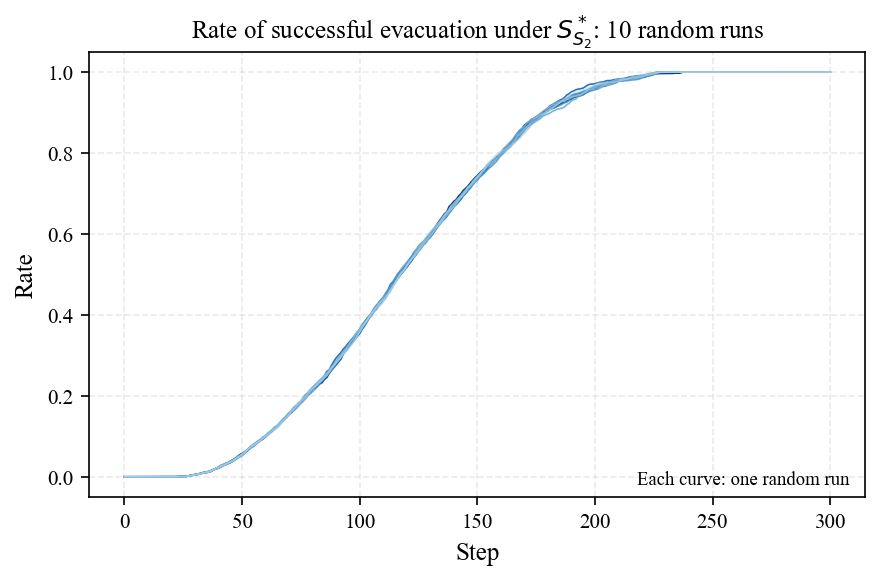

In [3]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib
import matplotlib.colors as mcolors

# 工科顶刊常用：衬线字体、高 DPI、矢量输出
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "SimSun"]
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["axes.labelsize"] = 12
matplotlib.rcParams["axes.titlesize"] = 12
matplotlib.rcParams["xtick.labelsize"] = 10
matplotlib.rcParams["ytick.labelsize"] = 10
matplotlib.rcParams["figure.dpi"] = 150

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\s2")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

fig, ax = plt.subplots(figsize=(6, 4))
n = len(files)
alphas = [0.55 + 0.45 * (n - 1 - i) / max(n - 1, 1) for i in range(n)]

cmap = plt.cm.Blues
colors = [cmap(0.3 + 0.65 * (n - 1 - i) / max(n - 1, 1)) for i in range(n)]

for i, f in enumerate(files):
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    ax.plot(step, mean, color=colors[i], alpha=alphas[i], linewidth=0.8)

ax.set_xlabel("Step")
ax.set_ylabel("Rate")
ax.set_title(r"Rate of successful evacuation under $S_{S_2}^*$: 10 random runs")
ax.text(0.98, 0.02, "Each curve: one random run", transform=ax.transAxes,
        fontsize=9, ha="right", va="bottom")
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
ax.tick_params(direction="out", length=4)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
plt.tight_layout()
plt.show()

In [23]:
import json
from pathlib import Path

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\s2")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

first_step_to_one = []
for f in files:
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    # 找到第一个 mean >= 1 的 step（“为1”按达到 1 理解，用 >=1 更稳）
    found = None
    for i, m in enumerate(mean):
        if m >= 1:
            found = step[i]
            break
    first_step_to_one.append(found)

# 只对有效值求平均
valid = [s for s in first_step_to_one if s is not None]
avg_step = sum(valid) / len(valid) if valid else None

print("每个文档最早为1的 step:", first_step_to_one)
print("有效文件数:", len(valid), "/", len(files))
print("平均值:", avg_step)

每个文档最早为1的 step: [238, 231, 232, 231, 233, 231, 231, 231, 232, 232]
有效文件数: 10 / 10
平均值: 232.2


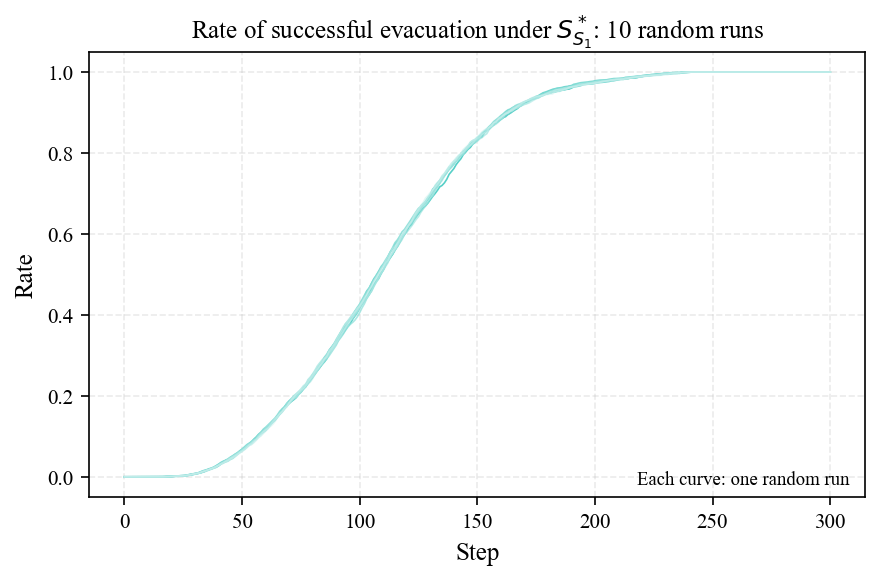

In [7]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# 工科顶刊常用：衬线字体、高 DPI、矢量输出
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "SimSun"]
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["axes.labelsize"] = 12
matplotlib.rcParams["axes.titlesize"] = 12
matplotlib.rcParams["xtick.labelsize"] = 10
matplotlib.rcParams["ytick.labelsize"] = 10
matplotlib.rcParams["figure.dpi"] = 150

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\s1")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

fig, ax = plt.subplots(figsize=(6, 4))
n = len(files)
alphas = [0.55 + 0.45 * (n - 1 - i) / max(n - 1, 1) for i in range(n)]

# 从浅色到青 #4ECDC4 的自定义 colormap（类似 Blues 的渐变风格）
cmap = LinearSegmentedColormap.from_list('cyan', ['#ffffff', '#4ECDC4'], N=256)
colors = [cmap(0.3 + 0.65 * (n - 1 - i) / max(n - 1, 1)) for i in range(n)]

for i, f in enumerate(files):
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    ax.plot(step, mean, color=colors[i], alpha=alphas[i], linewidth=0.8)

ax.set_xlabel("Step")
ax.set_ylabel("Rate")
ax.set_title(r"Rate of successful evacuation under $S_{S_1}^*$: 10 random runs")
ax.text(0.98, 0.02, "Each curve: one random run", transform=ax.transAxes,
        fontsize=9, ha="right", va="bottom")
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
ax.tick_params(direction="out", length=4)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
plt.tight_layout()
plt.show()

In [24]:
import json
from pathlib import Path

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\s1")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

first_step_to_one = []
for f in files:
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    # 找到第一个 mean >= 1 的 step（“为1”按达到 1 理解，用 >=1 更稳）
    found = None
    for i, m in enumerate(mean):
        if m >= 1:
            found = step[i]
            break
    first_step_to_one.append(found)

# 只对有效值求平均
valid = [s for s in first_step_to_one if s is not None]
avg_step = sum(valid) / len(valid) if valid else None

print("每个文档最早为1的 step:", first_step_to_one)
print("有效文件数:", len(valid), "/", len(files))
print("平均值:", avg_step)

每个文档最早为1的 step: [241, 242, 237, 240, 240, 240, 240, 242, 241]
有效文件数: 9 / 9
平均值: 240.33333333333334


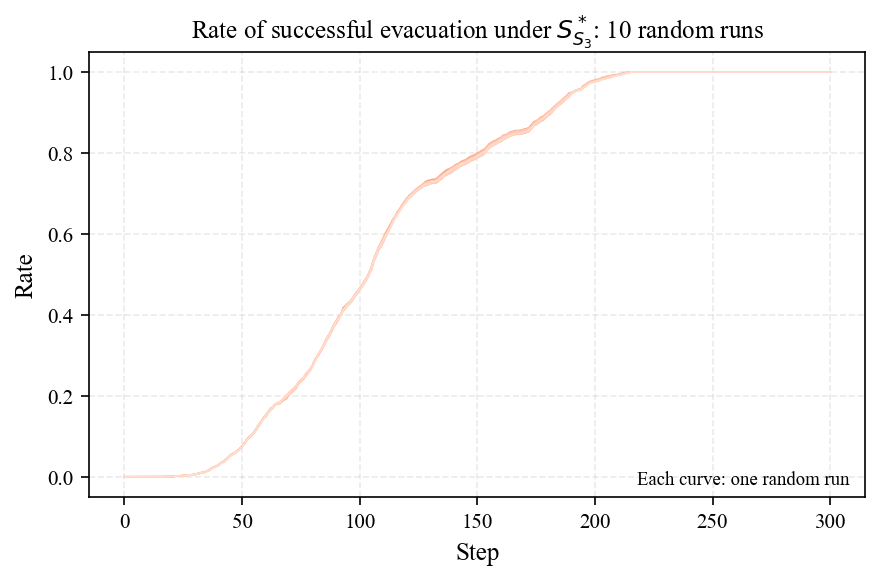

In [9]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# 工科顶刊常用：衬线字体、高 DPI、矢量输出
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "SimSun"]
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["axes.labelsize"] = 12
matplotlib.rcParams["axes.titlesize"] = 12
matplotlib.rcParams["xtick.labelsize"] = 10
matplotlib.rcParams["ytick.labelsize"] = 10
matplotlib.rcParams["figure.dpi"] = 150

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\s3")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

fig, ax = plt.subplots(figsize=(6, 4))
n = len(files)
alphas = [0.55 + 0.45 * (n - 1 - i) / max(n - 1, 1) for i in range(n)]


cmap = LinearSegmentedColormap.from_list('orange', ['#ffffff', '#FFA07A'], N=256)
colors = [cmap(0.3 + 0.65 * (n - 1 - i) / max(n - 1, 1)) for i in range(n)]

for i, f in enumerate(files):
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    ax.plot(step, mean, color=colors[i], alpha=alphas[i], linewidth=0.8)

ax.set_xlabel("Step")
ax.set_ylabel("Rate")
ax.set_title(r"Rate of successful evacuation under $S_{S_3}^*$: 10 random runs")
ax.text(0.98, 0.02, "Each curve: one random run", transform=ax.transAxes,
        fontsize=9, ha="right", va="bottom")
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
ax.tick_params(direction="out", length=4)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
plt.tight_layout()
plt.show()

In [25]:
import json
from pathlib import Path

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\s3")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

first_step_to_one = []
for f in files:
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    # 找到第一个 mean >= 1 的 step（“为1”按达到 1 理解，用 >=1 更稳）
    found = None
    for i, m in enumerate(mean):
        if m >= 1:
            found = step[i]
            break
    first_step_to_one.append(found)

# 只对有效值求平均
valid = [s for s in first_step_to_one if s is not None]
avg_step = sum(valid) / len(valid) if valid else None

print("每个文档最早为1的 step:", first_step_to_one)
print("有效文件数:", len(valid), "/", len(files))
print("平均值:", avg_step)

每个文档最早为1的 step: [214, 214, 218, 215, 215, 214, 214, 216, 215, 215]
有效文件数: 10 / 10
平均值: 215.0


In [29]:
import json
from pathlib import Path

base_dir = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s\b0_s3")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)

first_step_to_one = []
for f in files:
    with open(f, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    # 找到第一个 mean >= 1 的 step（“为1”按达到 1 理解，用 >=1 更稳）
    found = None
    for i, m in enumerate(mean):
        if m >= 1:
            found = step[i]
            break
    first_step_to_one.append(found)

# 只对有效值求平均
valid = [s for s in first_step_to_one if s is not None]
avg_step = sum(valid) / len(valid) if valid else None

print("每个文档最早为1的 step:", first_step_to_one)
print("有效文件数:", len(valid), "/", len(files))
print("平均值:", avg_step)

每个文档最早为1的 step: [226, 232, 223, 231, 236, 236, 240, 240, 235, 240]
有效文件数: 10 / 10
平均值: 233.9


已保存: d:\progamming\python_script\Social-physical-system-shelter\data_empirical\s1_s2_s3_combined.svg


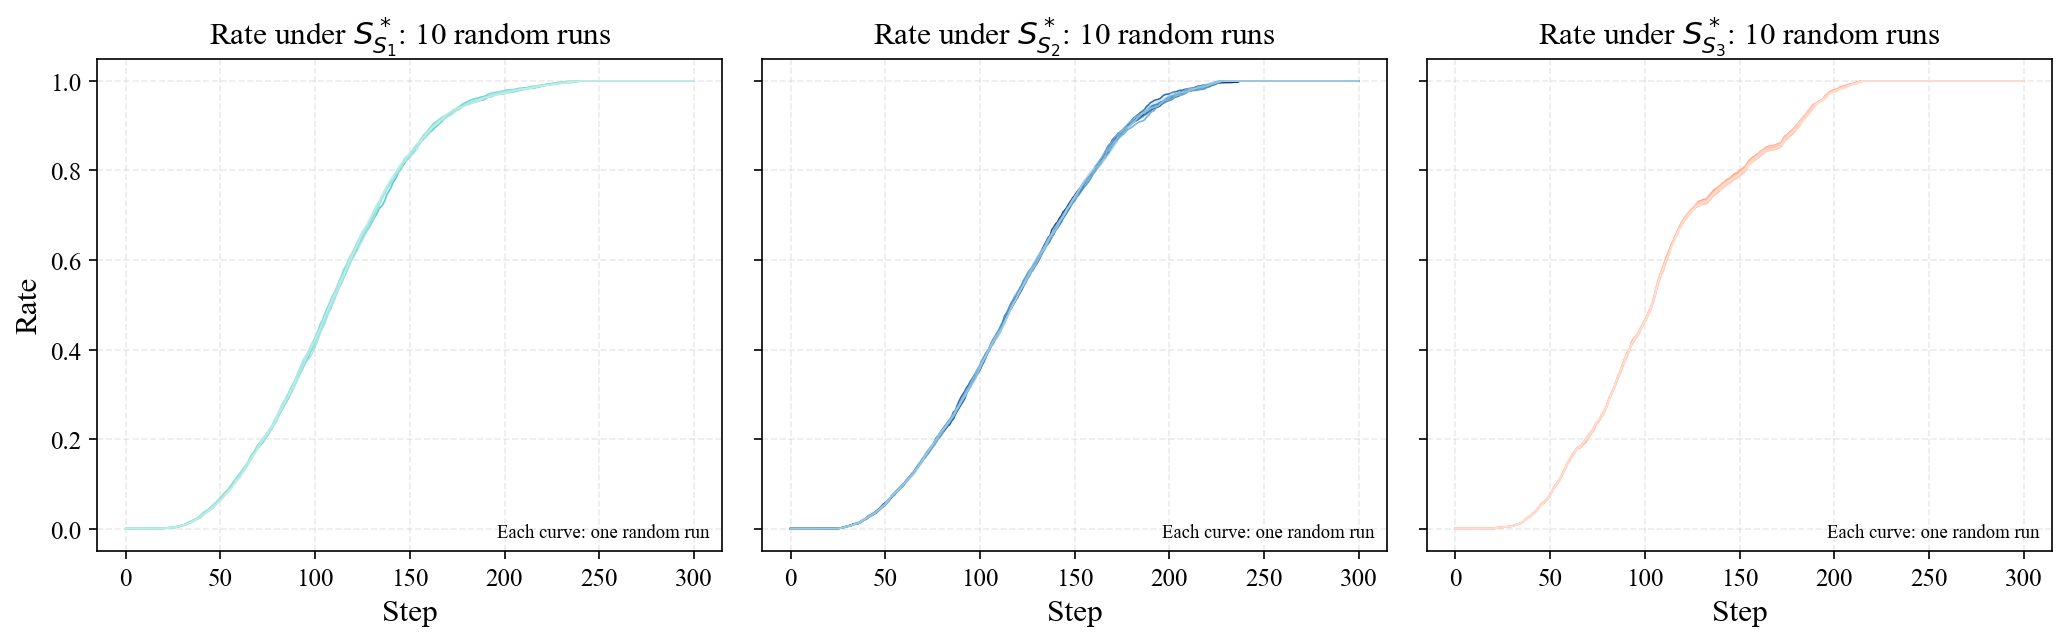

In [33]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

# 工科顶刊常用：衬线字体、高 DPI、矢量输出
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "SimSun"]
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["axes.labelsize"] = 15
matplotlib.rcParams["axes.titlesize"] = 15
matplotlib.rcParams["xtick.labelsize"] = 12
matplotlib.rcParams["ytick.labelsize"] = 12
matplotlib.rcParams["figure.dpi"] = 150

root = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s")

def sort_key(p):
    s = p.stem.replace("agent_speed_meanS", "")
    return int(s) if s.isdigit() else 0

# 三个子图：目录、colormap、标题
configs = [
    ("s1", LinearSegmentedColormap.from_list('cyan', ['#ffffff', '#4ECDC4'], N=256), r"$S_{S_1}^*$"),
    ("s2", plt.cm.Blues, r"$S_{S_2}^*$"),
    ("s3", LinearSegmentedColormap.from_list('orange', ['#ffffff', '#FFA07A'], N=256), r"$S_{S_3}^*$"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (folder, cmap, title) in zip(axes, configs):
    base_dir = root / folder
    files = sorted(base_dir.glob("agent_speed_meanS*.json"), key=sort_key)
    n = len(files)
    alphas = [0.55 + 0.45 * (n - 1 - i) / max(n - 1, 1) for i in range(n)]
    colors = [cmap(0.3 + 0.65 * (n - 1 - i) / max(n - 1, 1)) for i in range(n)]

    for i, f in enumerate(files):
        with open(f, "r", encoding="utf-8") as fp:
            data = json.load(fp)
        ax.plot(data["step"], data["mean"], color=colors[i], alpha=alphas[i], linewidth=0.8)

    ax.set_xlabel("Step")
    ax.set_ylabel("Rate" if ax is axes[0] else "")
    ax.set_title(r"Rate under " + title + ": 10 random runs")
    ax.text(0.98, 0.02, "Each curve: one random run", transform=ax.transAxes, fontsize=9, ha="right", va="bottom")
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

plt.tight_layout()

# 高分辨率 SVG 输出（矢量图本身即高分辨率，可再设 dpi 影响嵌入栅格）
out_path = Path(r"d:\progamming\python_script\Social-physical-system-shelter\data_empirical") / "s1_s2_s3_combined.svg"
plt.savefig(out_path, format="svg", bbox_inches="tight", pad_inches=0.2)
print("已保存:", out_path)
plt.show()

已保存: d:\progamming\python_script\Social-physical-system-shelter\data_empirical\first_step_boxplot.svg


C:\Users\yuyuio\AppData\Local\Temp\ipykernel_25040\2790755325.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


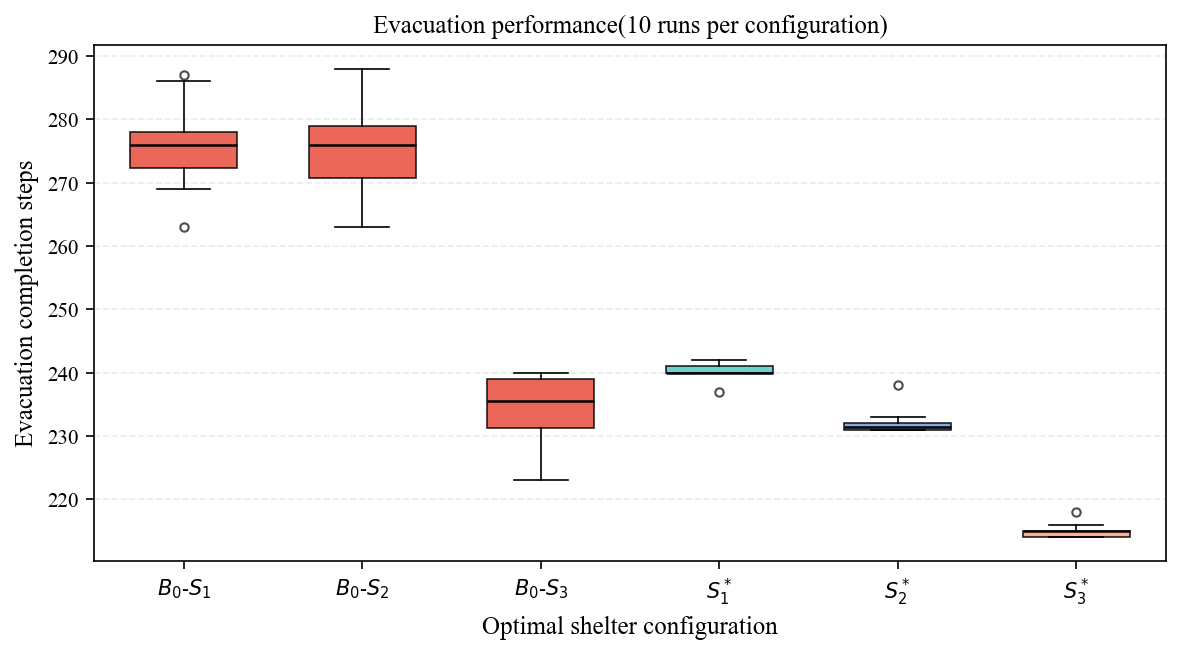

In [37]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib

# 顶刊风格：衬线字体、高 DPI
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "SimSun"]
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["axes.labelsize"] = 12
matplotlib.rcParams["axes.titlesize"] = 12
matplotlib.rcParams["xtick.labelsize"] = 10
matplotlib.rcParams["ytick.labelsize"] = 10
matplotlib.rcParams["figure.dpi"] = 150

root = Path(r"d:\progamming\python_script\Social-physical-system-shelter\experiments\ga_shelter\s")

folders = ["b0_s1", "b0_s2", "b0_s3", "s1", "s2", "s3"]
labels = [r"$B_0$-$S_1$", r"$B_0$-$S_2$", r"$B_0$-$S_3$", r"$S_1^*$", r"$S_2^*$", r"$S_3^*$"]

def first_step_to_one(file_path):
    with open(file_path, "r", encoding="utf-8") as fp:
        data = json.load(fp)
    step = data["step"]
    mean = data["mean"]
    for i, m in enumerate(mean):
        if m >= 1:
            return step[i]
    return None

data_by_group = []
for folder in folders:
    base_dir = root / folder
    files = list(base_dir.glob("agent_speed_mean*.json"))
    steps = []
    for f in files:
        s = first_step_to_one(f)
        if s is not None:
            steps.append(s)
    data_by_group.append(steps)

fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(
    data_by_group,
    labels=labels,
    patch_artist=True,
    widths=0.6,
    showfliers=True,
    flierprops=dict(marker="o", markersize=4, alpha=0.7),
    boxprops=dict(linewidth=0.8),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
)

# 配色：与之前曲线图一致，b0 稍浅，s 稍深
colors = ["#E74C3C", "#E74C3C", "#E74C3C", "#4ECDC4", "#6b9ed4", "#FFA07A"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_ylabel("Evacuation completion steps")
ax.set_xlabel("Optimal shelter configuration")
ax.set_title("Evacuation performance(10 runs per configuration)")
ax.grid(True, axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
ax.tick_params(direction="out", length=4)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
plt.tight_layout()


out_path = Path(r"d:\progamming\python_script\Social-physical-system-shelter\data_empirical") / "first_step_boxplot.svg"
plt.savefig(out_path, format="svg", bbox_inches="tight", pad_inches=0.2)
print("已保存:", out_path)
plt.show()